In [21]:
!pip install bchlib

In [36]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import sparse as sp
from scipy.sparse.linalg import factorized
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import pandas as pd
import seaborn as sns

def TBU_SNM(p, phi1, phi2, omega=0, tau=0):
    """
    TBU bidireccional usando las ecuaciones de Capmany mapeadas a SNM.
    Incluye sensibilidad a la frecuencia (omega) y retardo (tau).
    """
    # Coeficientes de los acopladores
    c_a, s_a = np.sqrt(1 - p['K_a']), np.sqrt(p['K_a'])
    c_b, s_b = np.sqrt(1 - p['K_b']), np.sqrt(p['K_b'])
    
    # El multiplicador incluye la pérdida y la fase de propagación global
    multiplicador = np.sqrt(1-p['gamma_a'])*np.sqrt(1-p['gamma_b'])*np.exp(-1j*omega*tau)
    
    # Fases efectivas (programada + frecuencia)
    theta1 = phi1 + omega * tau
    theta2 = phi2 + omega * tau

    # Coeficientes de la matriz de transferencia H from scipy.sparse.linalg import factorized
    
    m11 = c_a*c_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - s_a*s_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m12 = -1j*s_a*c_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - 1j*s_b*c_a*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m21 = -1j*s_b*c_a*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - 1j*s_a*c_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m22 = c_a*c_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2) - s_a*s_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1)

    # Matriz S local de 4x4 (mapea 4 nodos de entrada a 4 de salida) 
    # Puertos: a=0, c=1 (Entradas) | b=2, d=3 
    S_local = np.zeros((4, 4), dtype=complex)
    
    # Forward: In(a,c) -> Out(b,d)
    S_local[2, 0] = m11; S_local[2, 1] = m12
    S_local[3, 0] = m21; S_local[3, 1] = m22
    
    # Backward: In(b,d) -> Out(a,c) (Por reciprocidad Sij = Sji)
    S_local[0, 2] = m11; S_local[1, 2] = m12
    S_local[0, 3] = m21; S_local[1, 3] = m22
    
    return multiplicador * S_local

In [43]:
class malla_hexagonal:
    def __init__(self, tbus_por_columna, ideal=False, seed = None):
        # 1. Configuración de geometría
        self.tbus_reales = tbus_por_columna
        self.Cols = len(tbus_por_columna)
        self.Filas = max(tbus_por_columna) 
        
        self.ideal = ideal
        self.num_puertos = self.Cols * self.Filas * 4
        self.S = sp.lil_matrix((self.num_puertos, self.num_puertos), dtype=complex)
        
        self.seed = seed
        self.params_tbus = {} 
        self.cable_loss = 1.0 if ideal else 0.99
        self._inicializar_defectos() 

    def _existe_tbu(self, c, f):
        """Verifica si la TBU (c, f) es parte del diseño real."""
        if c < 0 or c >= self.Cols: return False
        if f < 0 or f >= self.tbus_reales[c]: return False
        return True

    def _get_ids(self, c, f):
        """Calcula los 4 IDs globales de una TBU."""
        base = (c * self.Filas + f) * 4 
        return base, base+1, base+2, base+3

    def _inicializar_defectos(self):
        
        if self.seed is not None:
            np.random.seed(self.seed)
            
            
        K_mean, K_std = 0.5, 0.0433
        g_c_m, g_c_s = 0.0115, 0.01
        g_a_m, g_a_s = 0.0516, 0.0284
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                if self.ideal:
                    self.params_tbus[(c,f)] = {
                        'K_a': 0.5, 'K_b': 0.5, 'gamma_a': 0.0115, 'gamma_b': 0.0115,
                        'gamma_c': 0.05160, 'gamma_d': 0.0516
                    }
                else:
                    self.params_tbus[(c,f)] = {
                        'K_a': np.clip(np.random.normal(K_mean, K_std), 0.0, 1.0),
                        'K_b': np.clip(np.random.normal(K_mean, K_std), 0.0, 1.0),
                        'gamma_a': np.clip(np.random.normal(g_c_m, g_c_s), 0.0, 1.0),
                        'gamma_b': np.clip(np.random.normal(g_c_m, g_c_s), 0.0, 1.0),
                        'gamma_c': np.clip(np.random.normal(g_a_m, g_a_s), 0.0, 1.0),
                        'gamma_d': np.clip(np.random.normal(g_a_m, g_a_s), 0.0, 1.0)
                    }
                    
    def colocar_tbus(self, fases_input):
        # Reiniciamos la matriz y conectamos cables antes de poner las TBUs
        self.S = sp.lil_matrix((self.num_puertos, self.num_puertos), dtype=complex)
        self._conectar_cables()
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                p = self.params_tbus[(c,f)]
                phi1, phi2 = fases_input.get((c,f), (0,0))
                
                # Invocamos tu función de matriz de transferencia (asegúrate de que esté definida)
                H = TBU_no_ideal_bidireccional(p['K_a'], p['K_b'], p['gamma_a'], p['gamma_b'], 
                                               p['gamma_c'], p['gamma_d'], phi1, phi2, 0, 0)
                ids = self._get_ids(c,f)
                for i in range(4):
                    for j in range(4):
                        if H[i, j] != 0:
                            self.S[ids[i], ids[j]] = H[i, j]

    def _conectar_cables(self):
        cable = self.cable_loss
        # 1. Bucle por todas las columnas (incluimos la última para procesar sus verticales)
        for c in range(self.Cols):
            tipo = c % 4
            num_f = self.tbus_reales[c]
            
            for f in range(num_f):
                # Obtenemos los 4 IDs de la TBU actual (c, f)
                it, ib, ot, ob = self._get_ids(c, f)
                
                # --- A. CONEXIONES VERTICALES (Solo en columnas Tipo 0 y Tipo 2) ---
                if (tipo == 0 or tipo == 2) and f < num_f - 1:
                    d_it, d_ib, d_ot, d_ob = self._get_ids(c, f + 1)
                    if tipo == 0:
                        if f % 2 == 0:
                            self.S[ob, d_ot] = cable; self.S[d_ot, ob] = cable
                        else:
                            self.S[ib, d_it] = cable; self.S[d_it, ib] = cable
                    elif tipo == 2:
                        # Lógica inversa para Tipo 2 según tu diseño
                        if f % 2 == 0:
                            self.S[ib, d_it] = cable; self.S[d_it, ib] = cable
                        else:
                            self.S[ob, d_ot] = cable; self.S[d_ot, ob] = cable

                # --- B. CONEXIONES HORIZONTALES (Hacia la columna c+1) ---
                if c < self.Cols - 1:
                    if tipo == 0: # Contracción 6 -> 3
                        f_dest = f // 2
                        target = self._get_ids(c + 1, f_dest)
                        if f % 2 == 1:
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        else:
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable

                    elif tipo == 1: # Expansión 3 -> 6
                        # Cada TBU en c conecta a dos en c+1
                        t_sup = self._get_ids(c + 1, 2 * f)
                        self.S[ot, t_sup[0]] = cable; self.S[t_sup[0], ot] = cable
                        t_inf = self._get_ids(c + 1, 2 * f + 1)
                        self.S[ob, t_inf[1]] = cable; self.S[t_inf[1], ob] = cable

                    elif tipo == 2: # Contracción 6 -> 4
                        if f == 0:
                            target = self._get_ids(c + 1, 0)
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        elif f == num_f - 1: # f=5
                            target = self._get_ids(c + 1, self.tbus_reales[c+1] - 1)
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable
                        else:
                            f_dest = ((f - 1) // 2) + 1
                            target = self._get_ids(c + 1, f_dest)
                            if f % 2 == 0:
                                self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                            else:
                                self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable

                    elif tipo == 3: # Expansión 4 -> 6 (LÓGICA DOBLE RESTAURADA)
                        if f == 0:
                            target = self._get_ids(c + 1, 0)
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        elif f == num_f - 1: # f=3
                            target = self._get_ids(c + 1, self.tbus_reales[c+1] - 1)
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable
                        else:
                            # TBUs centrales f=1, 2 conectan a DOS TBUs cada una
                            t_v_sup = self._get_ids(c + 1, 2 * f - 1)
                            self.S[ot, t_v_sup[0]] = cable; self.S[t_v_sup[0], ot] = cable
                            t_v_inf = self._get_ids(c + 1, 2 * f)
                            self.S[ob, t_v_inf[1]] = cable; self.S[t_v_inf[1], ob] = cable

    def detectar_puertos_externos(self):
        # Eliminamos la línea que reseteaba self.S
        # Solo calculamos cables si la matriz está vacía
        if self.S.nnz == 0:
            self._conectar_cables()
            
        S_csr = self.S.tocsr()
        puertos_externos = []
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                ids_tbu = self._get_ids(c, f)
                for p_id in ids_tbu:
                    # Un puerto es externo si NO tiene cables conectados
                    # Buscamos en la matriz de cables (que debería ser simétrica)
                    if S_csr[p_id, :].nnz == 0:
                        puertos_externos.append(p_id)
        return puertos_externos

    def obtener_ids_perimetrales_ordenados(self):
        ids_libres = self.detectar_puertos_externos()
        info_puertos = []
        for p_id in ids_libres:
            total_tbu_id = p_id // 4
            c = total_tbu_id // self.Filas
            f = total_tbu_id % self.Filas
            p_local = p_id % 4
            x = c
            y = f * 2 + (1 if c % 2 != 0 else 0)
            
            if c == 0: borde = 'WEST'
            elif c == self.Cols - 1: borde = 'EAST'
            elif p_local == 0 or p_local == 2: borde = 'NORTH'
            else: borde = 'SOUTH'
            info_puertos.append({'id': p_id, 'c': c, 'f': f, 'p_local': p_local, 'x': x, 'y': y, 'borde': borde})
        
        inicio = sorted([p for p in info_puertos if p['c'] == 0 and p['f'] == 0], key=lambda x: x['p_local'], reverse=True)
        norte = sorted([p for p in info_puertos if p['borde'] == 'NORTH' and 0 < p['c'] < self.Cols-1], key=lambda x: x['x'])
        este = sorted([p for p in info_puertos if p['borde'] == 'EAST'], key=lambda x: x['y'])
        sur = sorted([p for p in info_puertos if p['borde'] == 'SOUTH' and 0 < p['c'] < self.Cols-1], key=lambda x: x['x'], reverse=True)
        oeste_resto = sorted([p for p in info_puertos if p['c'] == 0 and p['f'] > 0], key=lambda x: x['y'], reverse=True)
        return [p['id'] for p in inicio + norte + este + sur + oeste_resto]

    def obtener_matriz_S_40x40(self, ids_puertos_40):
        # Aseguramos que la matriz esté en formato CSR para cálculos rápidos
        S_sparse = self.S.tocsr()
        
        # Resolvemos (I - S)x = b
        # Si ideal=True, usamos un factor de regularización para evitar matrices singulares
        reg = 1e-12 if self.ideal else 0
        I = sp.eye(self.num_puertos, format='csr') * (1 + reg)
        
        # Factorización LU para resolver rápido múltiples entradas
        solve = factorized((I - S_sparse).tocsc())
        
        num_ext = len(ids_puertos_40)
        S_puf = np.zeros((num_ext, num_ext), dtype=complex)
        
        for i in range(num_ext):
            b = np.zeros(self.num_puertos, dtype=complex)
            b[ids_puertos_40[i]] = 1.0 # Inyectamos 1 en el puerto i
            x = solve(b)
            # El resultado en los puertos externos es la respuesta de la red
            S_puf[:, i] = x[ids_puertos_40]
            
        return S_puf

In [44]:
class malla_SNM(malla_hexagonal):

    def __init__(self, tbus_por_columna, ideal=False, seed=None):

        super().__init__(tbus_por_columna, ideal, seed)

        # Cada puerto físico tiene un nodo de entrada (i) y uno de salida (o) [cite: 101]

        self.num_nodos = self.num_puertos * 2 

        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)



    def _get_nodos(self, p_id):

        """Retorna los índices (nodo_entrada, nodo_salida) para un puerto global[cite: 101]."""

        return p_id * 2, p_id * 2 + 1



    def construir_grafo(self, fases_input):

        """Mapea la estructura al grafo de flujo inicial[cite: 210]."""

        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)

        

        # 1. Conexiones internas (Nodos i -> Nodos o dentro de cada TBU) [cite: 102, 105]

        for (c, f), p in self.params_tbus.items():

            phi1, phi2 = fases_input.get((c, f), (0, 0))

            S_tbu = TBU_SNM(p, phi1, phi2)

            ids_puertos = self._get_ids(c, f)

            

            for i_local in range(4):

                for j_local in range(4):

                    if S_tbu[j_local, i_local] != 0:

                        # Nodo de entrada del puerto origen -> Nodo de salida del puerto destino

                        n_in = self._get_nodos(ids_puertos[i_local])[0]

                        n_out = self._get_nodos(ids_puertos[j_local])[1]

                        self.G[n_out, n_in] = S_tbu[j_local, i_local]



        # 2. Conexiones de cables (Nodos o -> Nodos i entre TBUs) [cite: 184]

        # Usamos la lógica de conectividad física previa

        malla_temp = malla_hexagonal(self.tbus_reales, self.ideal)

        malla_temp._conectar_cables()

        conn = malla_temp.S.tocoo()

        

        for p1, p2 in zip(conn.row, conn.col):

            if p1 < p2:

                # Cable une el nodo de salida de un puerto con el de entrada del otro [cite: 184]

                n1_in, n1_out = self._get_nodos(p1)

                n2_in, n2_out = self._get_nodos(p2)

                self.G[n2_in, n1_out] = self.cable_loss

                self.G[n1_in, n2_out] = self.cable_loss



    def resolver_matriz_total(self, ids_externos):

        """

        Calcula la matriz de scattering total entre los puertos externos[cite: 188, 24].

        Equivale a simplificar todos los nodos internos[cite: 187, 873].

        """

        # I - G representa la matriz de conexiones de toda la red [cite: 211]

        I = sp.eye(self.num_nodos, format='csr')

        A = (I - self.G.tocsr()).tocsc()

        solve = factorized(A)

        

        num_ext = len(ids_externos)

        S_total = np.zeros((num_ext, num_ext), dtype=complex)

        

        for j in range(num_ext):

            # Inyectamos señal en el nodo de entrada (i) del puerto externo j [cite: 24, 39]

            b = np.zeros(self.num_nodos, dtype=complex)

            n_in_j = self._get_nodos(ids_externos[j])[0]

            b[n_in_j] = 1.0

            

            x = solve(b)

            

            # La respuesta está en los nodos de salida (o) de los puertos externos [cite: 101, 102]

            for i in range(num_ext):

                n_out_i = self._get_nodos(ids_externos[i])[1]

                S_total[i, j] = x[n_out_i]

                

        return S_total 

In [45]:
class malla_SNM_completa(malla_SNM):
    def __init__(self, tbus_por_columna, ideal=False, seed=None):
        super().__init__(tbus_por_columna, ideal, seed)
        self.mapa_tbus = self._generar_mapa_tbus()

    def _generar_mapa_tbus(self):
        """Crea el diccionario: Índice Lineal -> (Columna, Fila)"""
        mapa = {}
        contador = 0
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                mapa[contador] = (c, f)
                contador += 1
        return mapa

    def programar_malla(self, config_usuario, omega=0, tau=0, fase_comun=0):
        """
        Programación de la malla incluyendo el Overall Phase Shift (fase_comun)
        y soporte para fases totalmente aleatorias (tuplas).
        """
        fases_finales = {}

        for idx_lineal, estado in config_usuario:
            if idx_lineal in self.mapa_tbus:
                coords = self.mapa_tbus[idx_lineal]

                # 1. Determinamos la fase diferencial (phi) según el estado
                # --- CAMBIO AQUÍ: Soporte para tuplas aleatorias ---
                if isinstance(estado, tuple):
                    phi1, phi2 = estado  # Usamos las fases aleatorias directamente
                # ---------------------------------------------------
                elif estado == "x":
                    phi1, phi2 = (0, 0) # CROSS 
                elif estado == "=":
                    phi1, phi2 = (np.pi, 0) # BAR 
                elif isinstance(estado, (int, float)):
                    theta = 2 * np.arcsin(np.sqrt(estado))
                    phi1, phi2 = (theta, 0)
                else:
                    phi1, phi2 = (0, 0)

                # 2. Aplicamos la FASE COMÚN a ambos brazos
                fases_finales[coords] = (phi1 + fase_comun, phi2 + fase_comun)

        # 3. Construimos el grafo con las fases ya desplazadas
        self.construir_grafo_espectral(fases_finales, omega, tau)

    
    def construir_grafo_espectral(self, fases_input, omega, tau):
        """
        Construye el grafo de flujo de señal considerando la fase de propagación[cite: 90, 862].
        """
        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)
        
        # 1. Conexiones internas de las TBUs con dependencia espectral [cite: 102, 105]
        for (c, f), p in self.params_tbus.items():
            phi1, phi2 = fases_input.get((c, f), (0, 0))
            # Usamos tu función TBU_SNM que ya incluye omega y tau 
            S_tbu = TBU_SNM(p, phi1, phi2, omega, tau)
            ids_puertos = self._get_ids(c, f)
            
            for i_local in range(4):
                for j_local in range(4):
                    if S_tbu[j_local, i_local] != 0:
                        n_in = self._get_nodos(ids_puertos[i_local])[0]
                        n_out = self._get_nodos(ids_puertos[j_local])[1]
                        self.G[n_out, n_in] = S_tbu[j_local, i_local]
    
        # 2. Conexiones de cables con fase de retardo (tau) [cite: 184]
        # El cable también añade un desfase complejo según la frecuencia 
        fase_cable = np.exp(-1j * omega * tau) 
        
        # Usamos una malla temporal para identificar conexiones físicas [cite: 210]
        malla_temp = malla_hexagonal(self.tbus_reales, self.ideal)
        malla_temp._conectar_cables()
        conn = malla_temp.S.tocoo()
        
        for p1, p2 in zip(conn.row, conn.col):
            if p1 < p2:
                n1_in, n1_out = self._get_nodos(p1)
                n2_in, n2_out = self._get_nodos(p2)
                # Conexión bidireccional entre nodos Out e In de puertos adyacentes [cite: 184]
                self.G[n2_in, n1_out] = self.cable_loss * fase_cable
                self.G[n1_in, n2_out] = self.cable_loss * fase_cable

In [46]:
def graficar_salida_dbm(potencias_lineales, ids_p):
    """
    Gráfico de potencias en dBm con todos los porcentajes en vertical para evitar solapes.
    """
    suelo = -60 
    # El paper utiliza escalas logarítmicas para analizar la transmisión [cite: 862]
    potencias_dbm = 10 * np.log10(potencias_lineales + 1e-12) 
    alturas = np.maximum(potencias_dbm, suelo) - suelo
    
    plt.figure(figsize=(15, 7))
    
    # Colores: Salmón para puertos con señal (>1%), azul para el resto [cite: 850]
    colores = ['#ff7f50' if p > 0.01 else '#87ceeb' for p in potencias_lineales]
    
    plt.bar(range(len(ids_p)), alturas, bottom=suelo, 
            color=colores, edgecolor='black', alpha=0.8)
    
    for i, p in enumerate(potencias_lineales):
        es_relevante = p > 0.01
        quiero 
        # Posición base del texto (mínimo un poco por encima del suelo)
        y_pos = max(potencias_dbm[i], suelo + 1)
        
        # Configuración para que todos sean verticales
        plt.text(i, y_pos + 1, f"{p*100:.1f}%", 
                 ha='center', va='bottom', 
                 fontsize=7.5, 
                 fontweight='bold' if es_relevante else 'normal',
                 rotation=90, # <--- Todos en vertical
                 alpha=1.0 if es_relevante else 0.7)

    # Damos margen arriba para que quepan los números verticales
    plt.ylim([suelo, 15]) 
    plt.ylabel("Potencia (dBm)")
    plt.xlabel("Índice de Puerto de Salida (S)")
    plt.title("Distribución de Potencia por Puerto - Método SNM")
    
    plt.grid(axis='y', linestyle=':', alpha=0.4)
    plt.xticks(range(len(ids_p)), range(len(ids_p)), fontsize=8)
    
    plt.tight_layout()
    plt.show()
def preparar_fases(config_usuario, fase_comun=0):
    """
    Traduce estados semánticos a fases físicas añadiendo un Overall Phase Shift.
    fase_comun: Desplazamiento global que se aplica a todas las TBUs.
    """
    fases = {}
    for (tbu_id, estado) in config_usuario:
        # 1. Calculamos la fase diferencial base (la que controla el puerto de salida)
        if estado == "x":
            phi1_base, phi2_base = (0, 0)
        elif estado == "=":
            phi1_base, phi2_base = (np.pi, 0)
        elif isinstance(estado, (int, float)):
            phi1_base, phi2_base = (2 * np.arcsin(np.sqrt(estado)), 0)
        else:
            phi1_base, phi2_base = (0, 0)

        # 2. Implementamos el "Overall Phase Shift" sumando la fase común a AMBOS brazos
        # Esto es lo que te pedía tu jefe: Psi = (theta1 + theta2) / 2
        fases[tbu_id] = (phi1_base + fase_comun, phi2_base + fase_comun)
        
    return fases

def generar_configuracion_totalmente_aleatoria(malla, seed):
    """
    Genera fases phi1 y phi2 totalmente aleatorias [0, 2*pi] para cada TBU.
    """
    np.random.seed(seed)
    config = []
    for idx_lineal in malla.mapa_tbus.keys():
        # Generamos dos fases independientes para los dos brazos del MZI (Phase Shifters)
        phi1_rand = np.random.uniform(0, 2 * np.pi)
        phi2_rand = np.random.uniform(0, 2 * np.pi)
        
        config.append((idx_lineal, (phi1_rand, phi2_rand)))
    return config
def calcular_metricas_puf(p1, p2):
    # 1. Correlación de Pearson (1 = idénticos, 0 = sin relación)
    # En una buena PUF, la correlación debe ser baja
    corr, _ = pearsonr(p1, p2)
    
    # 2. Distancia Euclidiana (Cuanto mayor, más diferentes son los chips)
    dist_euclidea = np.linalg.norm(p1 - p2)
    
    # 3. Diferencia Porcentual Media (MAE en escala lineal)
    mae = np.mean(np.abs(p1 - p2)) * 100
    
    # 4. Superposición de Potencia (Similarity Score)
    # Calculamos cuánto de la potencia cae en los mismos puertos
    overlap = np.sum(np.minimum(p1, p2)) / np.sum(p1) * 100

    print("--- MÉTRICAS DE COMPARACIÓN INTER-CHIP ---")
    print(f"1. Correlación de Pearson: {corr:.4f}")
    print(f"2. Distancia Euclidiana:  {dist_euclidea:.4f}")
    print(f"3. Error Medio Absoluto:  {mae:.2f} %")
    print(f"4. Similitud de Perfil:   {overlap:.2f} %")
    print("-" * 42)
    
    if corr < 0.7:
        print("RESULTADO: Alta Unicidad. Los chips son fácilmente distinguibles. ✅")
    else:
        print("RESULTADO: Baja Unicidad. Los chips se parecen demasiado. ⚠️")

Simulando 1000 chips... Esto puede tardar unos segundos.
>> Procesados 100 / 1000 chips...
>> Procesados 200 / 1000 chips...
>> Procesados 300 / 1000 chips...
>> Procesados 400 / 1000 chips...
>> Procesados 500 / 1000 chips...
>> Procesados 600 / 1000 chips...
>> Procesados 700 / 1000 chips...
>> Procesados 800 / 1000 chips...
>> Procesados 900 / 1000 chips...
>> Procesados 1000 / 1000 chips...


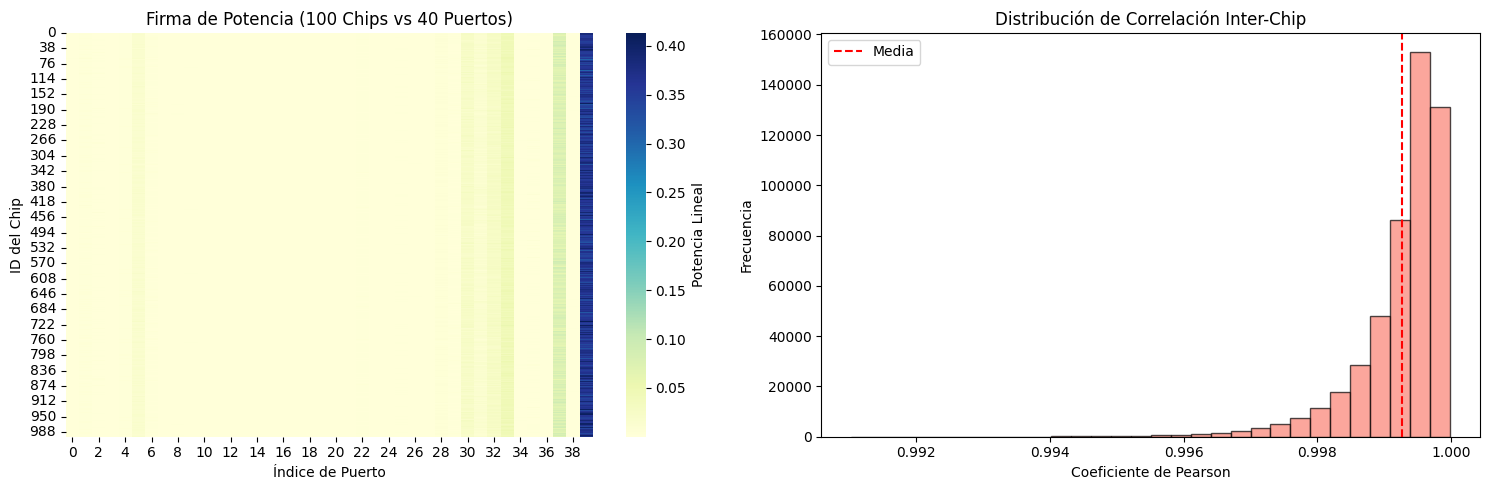

Análisis completado. Correlación media entre chips: 0.9993


In [47]:


# 1. Configuración de la población
num_chips = 1000
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
seed_del_reto = 45

# 2. Generar el reto único para todos
malla_base = malla_SNM_completa(tbus_columnas)
reto = generar_configuracion_totalmente_aleatoria(malla_base, seed=seed_del_reto)
fase_comun_puf = np.random.uniform(0, 2*np.pi)

# 3. Bucle de simulación masiva
print(f"Simulando {num_chips} chips... Esto puede tardar unos segundos.")
resultados_potencia = []

for i in range(num_chips):
    # Cada chip tiene una semilla de fabricación única (i)
    malla_i = malla_SNM_completa(tbus_columnas, ideal=False, seed=i)
    malla_i.programar_malla(reto, fase_comun=fase_comun_puf)
    
    ids_40 = malla_i.obtener_ids_perimetrales_ordenados()
    S_i = malla_i.resolver_matriz_total(ids_40)
    
    # Guardamos la respuesta (inyectando por puerto 0)
    potencias = np.abs(S_i[:, 0])**2
    resultados_potencia.append(potencias)
    if (i + 1) % 100 == 0:
        print(f">> Procesados {i + 1} / {num_chips} chips...")
# Convertimos a matriz para procesar rápido (100 chips x 40 puertos)
matriz_puf = np.array(resultados_potencia)

# 4. Cálculo de la Matriz de Correlación (¿Qué tan diferentes son entre sí?)
# Calculamos la correlación entre todos los pares de chips posibles
df_puf = pd.DataFrame(matriz_puf.T) # Transponemos para que los puertos sean filas
matriz_corr = df_puf.corr()

# 5. Visualización Estadística
plt.figure(figsize=(15, 5))

# --- Gráfico A: Mapa de Calor de Potencias ---
plt.subplot(1, 2, 1)
sns.heatmap(matriz_puf[:, :], cmap='YlGnBu', cbar_kws={'label': 'Potencia Lineal'})
plt.title("Firma de Potencia (100 Chips vs 40 Puertos)")
plt.xlabel("Índice de Puerto")
plt.ylabel("ID del Chip")

# --- Gráfico B: Histograma de Correlaciones ---
plt.subplot(1, 2, 2)
# Extraemos solo el triángulo superior de la matriz de correlación (evitar repetidos y diagonal)
correlaciones_inter_chip = matriz_corr.values[np.triu_indices_from(matriz_corr, k=1)]
plt.hist(correlaciones_inter_chip, bins=30, color='salmon', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(correlaciones_inter_chip), color='red', linestyle='--', label=f'Media')
plt.title("Distribución de Correlación Inter-Chip")
plt.xlabel("Coeficiente de Pearson")
plt.ylabel("Frecuencia")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Análisis completado. Correlación media entre chips: {np.mean(correlaciones_inter_chip):.4f}")

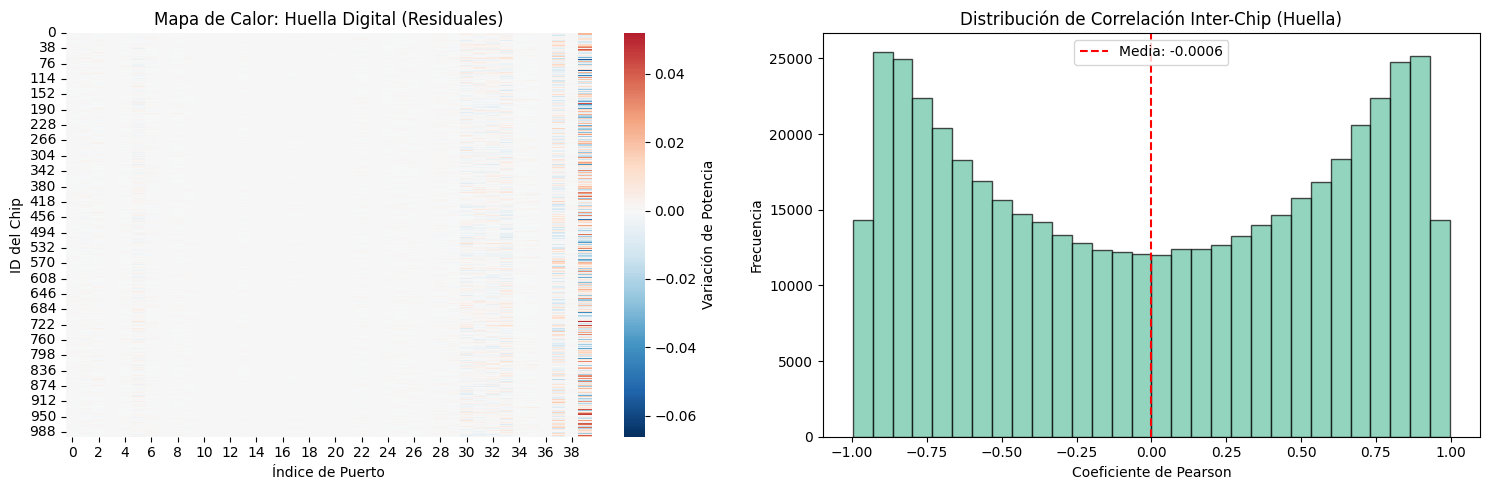

Análisis completado. Correlación media de la huella digital: -0.0006


In [48]:
# 1. Calculamos la respuesta media de todos los chips (el "patrón común")
potencia_media = np.mean(matriz_puf, axis=0)

# 2. Restamos la media a cada chip para obtener SOLO la huella digital (el error)
huella_digital = matriz_puf - potencia_media

# 3. Calculamos la correlación sobre la HUELLA DIGITAL
df_huella = pd.DataFrame(huella_digital.T)
matriz_corr_puf = df_huella.corr()
correlaciones_puras = matriz_corr_puf.values[np.triu_indices_from(matriz_corr_puf, k=1)]

# 5. Visualización Estadística (Misma estructura que la celda anterior)
plt.figure(figsize=(15, 5))

# --- Gráfico A: Mapa de Calor de la Huella Digital ---
plt.subplot(1, 2, 1)
# Usamos un mapa de color divergente (RdBu_r) para resaltar valores sobre/bajo la media
sns.heatmap(huella_digital, cmap='RdBu_r', center=0, cbar_kws={'label': 'Variación de Potencia'})
plt.title("Mapa de Calor: Huella Digital (Residuales)")
plt.xlabel("Índice de Puerto")
plt.ylabel("ID del Chip")

# --- Gráfico B: Histograma de Correlaciones de la Huella ---
plt.subplot(1, 2, 2)
# Cambiamos el color para diferenciarlo de la potencia bruta
plt.hist(correlaciones_puras, bins=30, color='#66c2a5', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(correlaciones_puras), color='red', linestyle='--', 
            label=f'Media: {np.mean(correlaciones_puras):.4f}')
plt.title("Distribución de Correlación Inter-Chip (Huella)")
plt.xlabel("Coeficiente de Pearson")
plt.ylabel("Frecuencia")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Análisis completado. Correlación media de la huella digital: {np.mean(correlaciones_puras):.4f}")

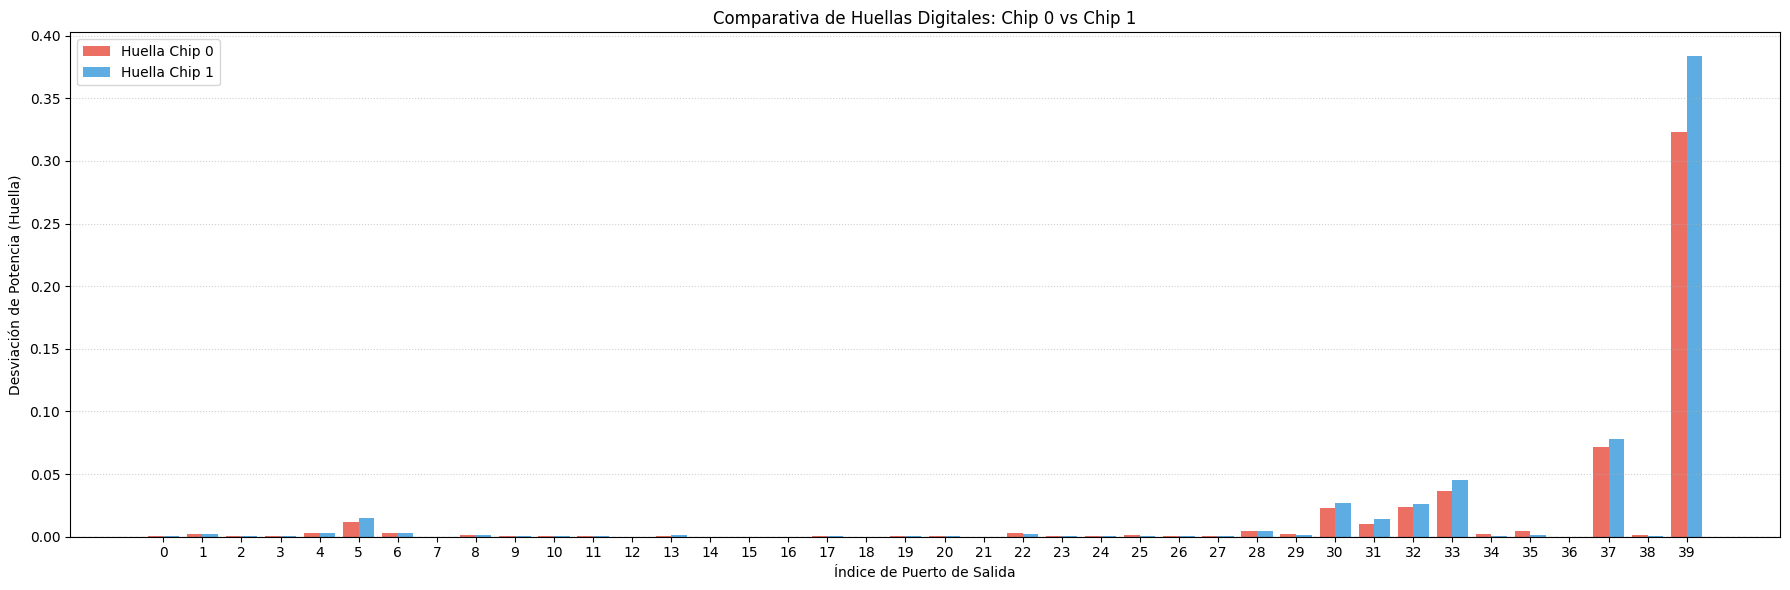

In [20]:
# 1. Seleccionamos los chips a comparar
chip_a = 0
chip_b = 1

# 2. Creamos la gráfica de barras
plt.figure(figsize=(18, 6))
x = np.arange(len(ids_40))  # Los 40 puertos
width = 0.4  # Ancho de las barras

# Barras para el Chip A
plt.bar(x - width/2, matriz_puf[chip_a], width, 
        label=f'Huella Chip {chip_a}', color='#e74c3c', alpha=0.8)

# Barras para el Chip B
plt.bar(x + width/2, matriz_puf[chip_b], width, 
        label=f'Huella Chip {chip_b}', color='#3498db', alpha=0.8)

# 3. Estética y etiquetas
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # Línea de "Media"
plt.title(f"Comparativa de Huellas Digitales: Chip {chip_a} vs Chip {chip_b}")
plt.xlabel("Índice de Puerto de Salida")
plt.ylabel("Desviación de Potencia (Huella)")
plt.xticks(x, range(len(ids_40)))
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

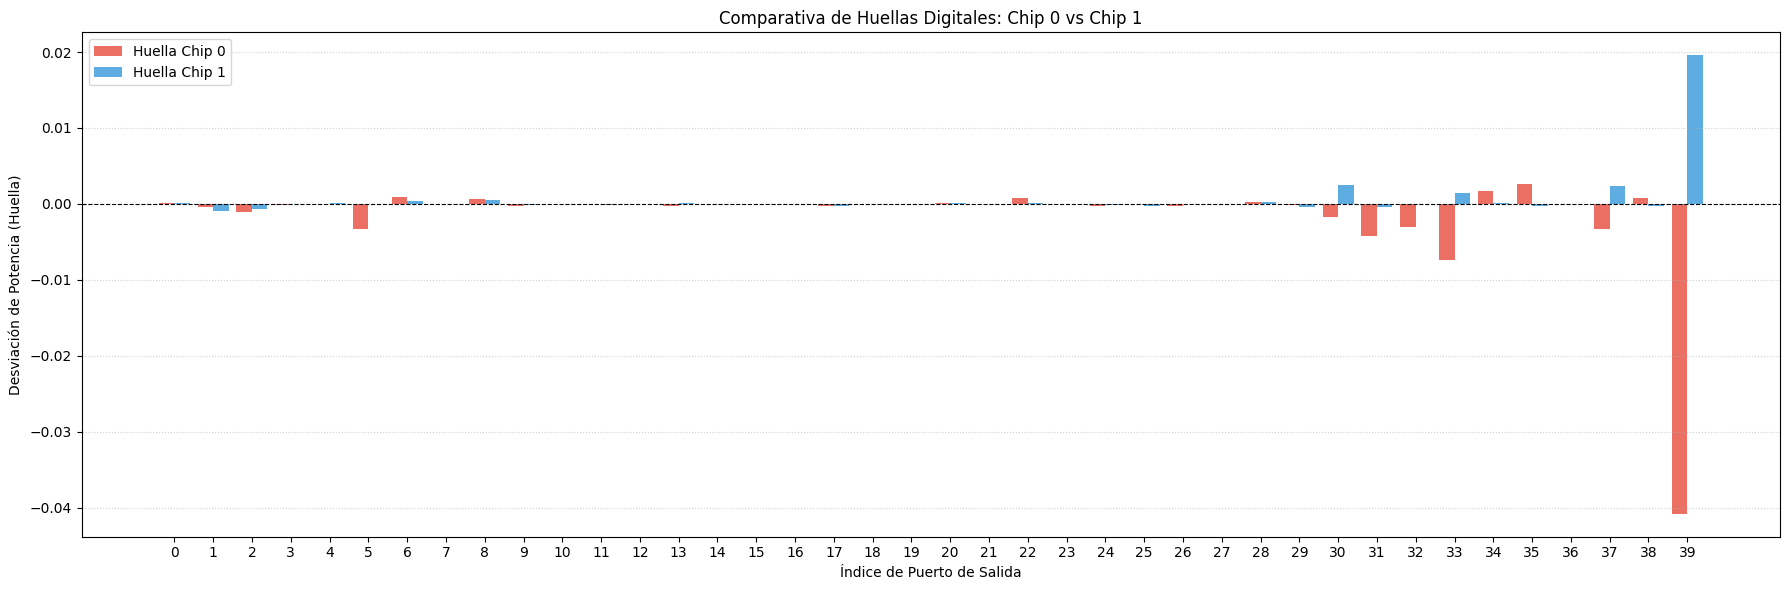

In [24]:
# 2. Creamos la gráfica de barras
plt.figure(figsize=(18, 6))
x = np.arange(len(ids_40))  # Los 40 puertos
width = 0.4  # Ancho de las barras

# Barras para el Chip A
plt.bar(x - width/2, huella_digital[chip_a], width, 
        label=f'Huella Chip {chip_a}', color='#e74c3c', alpha=0.8)

# Barras para el Chip B
plt.bar(x + width/2, huella_digital[chip_b], width, 
        label=f'Huella Chip {chip_b}', color='#3498db', alpha=0.8)

# 3. Estética y etiquetas
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # Línea de "Media"
plt.title(f"Comparativa de Huellas Digitales: Chip {chip_a} vs Chip {chip_b}")
plt.xlabel("Índice de Puerto de Salida")
plt.ylabel("Desviación de Potencia (Huella)")
plt.xticks(x, range(len(ids_40)))
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


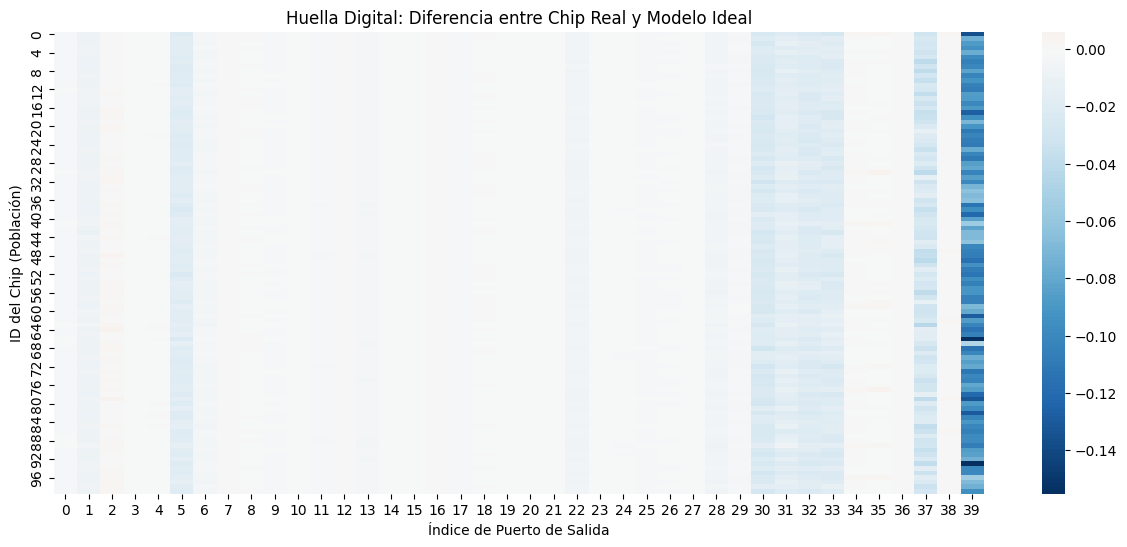

Correlación entre la huella del Chip 0 y Chip 1: 0.9863
Si este valor es cercano a 0, has demostrado que cada chip se desvía del ideal de forma única.


In [18]:
# 1. Creamos la MALLA IDEAL (Sin errores de fabricación)
malla_ideal = malla_SNM_completa(tbus_columnas, ideal=True)

# 2. La programamos con el MISMO RETO y la misma fase común
malla_ideal.programar_malla(reto, fase_comun=fase_comun_puf)
ids_40 = malla_ideal.obtener_ids_perimetrales_ordenados()
S_ideal = malla_ideal.resolver_matriz_total(ids_40)

# 3. Respuesta teórica (tu regla de medir)
potencia_ideal = np.abs(S_ideal[:, 0])**2

# 4. Calculamos la HUELLA DIGITAL respecto al modelo ideal
# Restamos la potencia ideal a cada uno de los 100 chips que ya simulamos
huella_respecto_ideal = matriz_puf - potencia_ideal

# 5. Visualización de la Huella "Real"
plt.figure(figsize=(15, 6))
sns.heatmap(huella_respecto_ideal, cmap='RdBu_r', center=0)
plt.title("Huella Digital: Diferencia entre Chip Real y Modelo Ideal")
plt.xlabel("Índice de Puerto de Salida")
plt.ylabel("ID del Chip (Población)")
plt.show()

# 6. MÉTRICA DE UNICIDAD: Correlación entre las huellas de dos chips distintos
# Elegimos el Chip 0 y el Chip 1 para ver si sus "errores" se parecen
from scipy.stats import pearsonr
corr_puf, _ = pearsonr(huella_respecto_ideal[0], huella_respecto_ideal[1])

print(f"Correlación entre la huella del Chip 0 y Chip 1: {corr_puf:.4f}")
print("Si este valor es cercano a 0, has demostrado que cada chip se desvía del ideal de forma única.")

Iniciando simulación de 1000 configuraciones en el mismo hardware...
>> Procesadas 100 / 1000 configuraciones...
>> Procesadas 200 / 1000 configuraciones...
>> Procesadas 300 / 1000 configuraciones...
>> Procesadas 400 / 1000 configuraciones...
>> Procesadas 500 / 1000 configuraciones...
>> Procesadas 600 / 1000 configuraciones...
>> Procesadas 700 / 1000 configuraciones...
>> Procesadas 800 / 1000 configuraciones...
>> Procesadas 900 / 1000 configuraciones...
>> Procesadas 1000 / 1000 configuraciones...


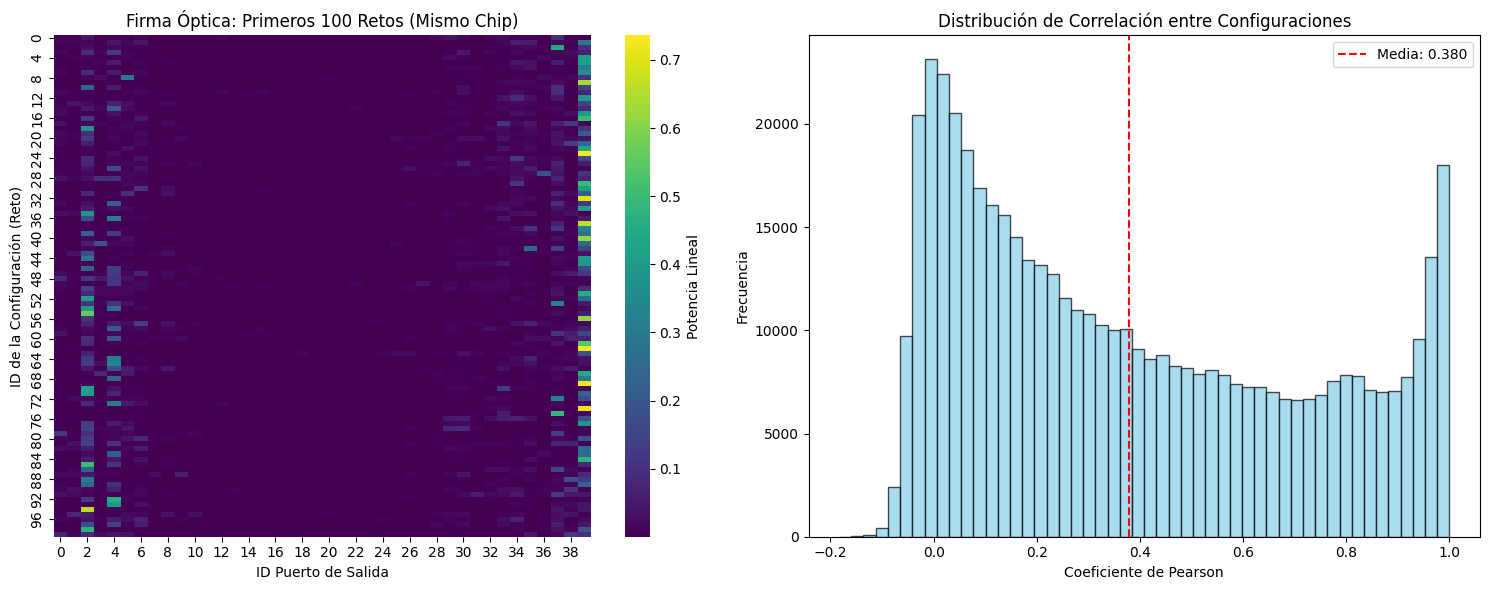

Análisis completado.
Correlación media entre retos: 0.3795


In [49]:
# --- EXPERIMENTO: 1000 RETOS ALEATORIOS EN UN MISMO CHIP ---

# 1. Configuración de la prueba
num_configs = 1000
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
seed_fijo_chip = 0  # Fijamos la fabricación del chip (siempre el mismo)

# 2. Instanciar el chip físico (una sola vez)
# Usamos ideal=False para incluir los defectos de fabricación reales
malla_instancia = malla_SNM_completa(tbus_columnas, ideal=False, seed=seed_fijo_chip)
ids_40 = malla_instancia.obtener_ids_perimetrales_ordenados()

print(f"Iniciando simulación de {num_configs} configuraciones en el mismo hardware...")
resultados_configs = []

# 3. Bucle de retos (Challenges)
for i in range(num_configs):
    # Generamos un "reto" (configuración de fases) diferente en cada iteración
    # Usamos la semilla 'i' para que cada configuración sea distinta pero reproducible
    reto_i = generar_configuracion_totalmente_aleatoria(malla_instancia, seed=i)
    
    # Programamos la malla con este reto específico
    malla_instancia.programar_malla(reto_i)
    
    # Resolvemos la respuesta óptica (inyectando por el puerto 0)
    S_i = malla_instancia.resolver_matriz_total(ids_40)
    potencias = np.abs(S_i[:, 0])**2
    
    resultados_configs.append(potencias)
    
    # Mensaje de progreso cada 100 configuraciones
    if (i + 1) % 100 == 0:
        print(f">> Procesadas {i + 1} / {num_configs} configuraciones...")

# Convertimos a matriz (1000 retos x 40 puertos)
matriz_configs = np.array(resultados_configs)

# 4. Análisis de Correlación Inter-Reto (¿Cómo de diferentes son las respuestas?)
# Transponemos para correlacionar las respuestas (filas) entre sí
df_configs = pd.DataFrame(matriz_configs.T)
matriz_corr_configs = df_configs.corr()

# Extraemos el triángulo superior para evitar la diagonal y duplicados
correlaciones_inter_config = matriz_corr_configs.values[np.triu_indices_from(matriz_corr_configs, k=1)]

# 5. Visualización de resultados
plt.figure(figsize=(15, 6))

# --- Gráfico A: Mapa de Calor de los primeros 100 retos ---
# (Mostramos solo 100 para que sea visualmente legible)
plt.subplot(1, 2, 1)
sns.heatmap(matriz_configs[:100, :], cmap='viridis', cbar_kws={'label': 'Potencia Lineal'})
plt.title("Firma Óptica: Primeros 100 Retos (Mismo Chip)")
plt.xlabel("ID Puerto de Salida")
plt.ylabel("ID de la Configuración (Reto)")

# --- Gráfico B: Histograma de Correlación entre Retos ---
plt.subplot(1, 2, 2)
plt.hist(correlaciones_inter_config, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(correlaciones_inter_config), color='red', linestyle='--', 
            label=f'Media: {np.mean(correlaciones_inter_config):.3f}')
plt.title("Distribución de Correlación entre Configuraciones")
plt.xlabel("Coeficiente de Pearson")
plt.ylabel("Frecuencia")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Análisis completado.")
print(f"Correlación media entre retos: {np.mean(correlaciones_inter_config):.4f}")

In [50]:
# --- AUDITORÍA DE COLISIONES ---
max_corr = np.max(correlaciones_inter_config)
min_corr = np.min(correlaciones_inter_config)
# Contamos cuántas parejas superan un umbral crítico (ej. 0.9)
colisiones_potenciales = np.sum(correlaciones_inter_config > 0.9)

print(f"--- RESULTADOS DE SEGURIDAD CRÍTICA ---")
print(f"Correlación Máxima detectada: {max_corr:.6f}")
print(f"Correlación Mínima detectada: {min_corr:.6f}")
print(f"Número de pares con similitud > 90%: {colisiones_potenciales}")

if max_corr > 0.99:
    print("¡PELIGRO! Tienes colisiones. Diferentes retos dan la misma respuesta. ⚠️")
else:
    print("No hay colisiones exactas, pero la estructura tiene memoria. ✅")

--- RESULTADOS DE SEGURIDAD CRÍTICA ---
Correlación Máxima detectada: 0.999992
Correlación Mínima detectada: -0.183431
Número de pares con similitud > 90%: 50429
¡PELIGRO! Tienes colisiones. Diferentes retos dan la misma respuesta. ⚠️


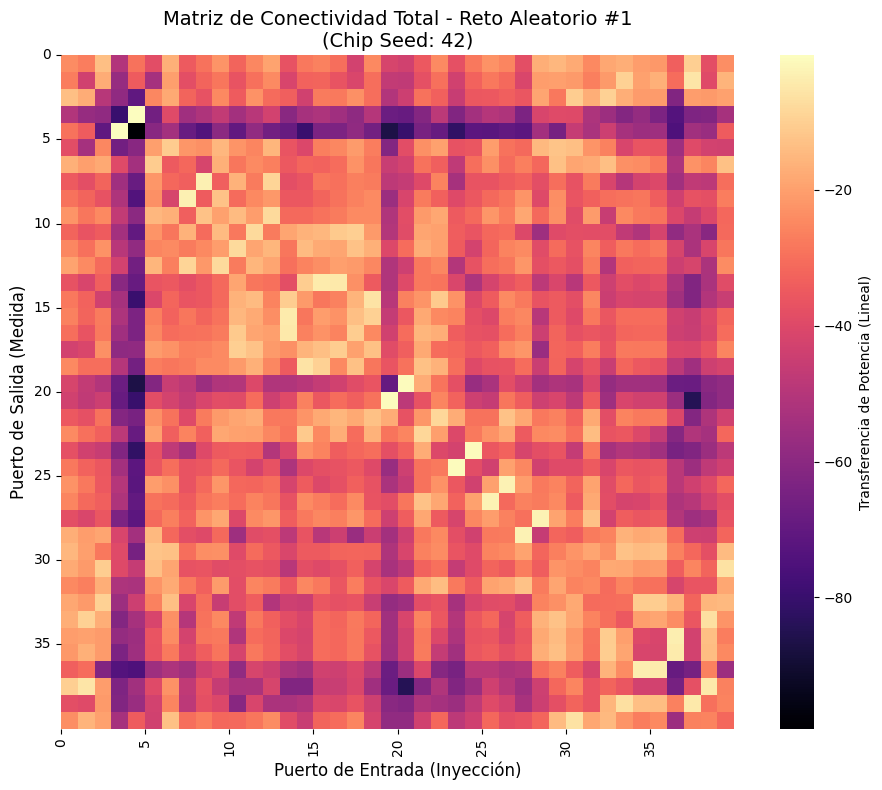

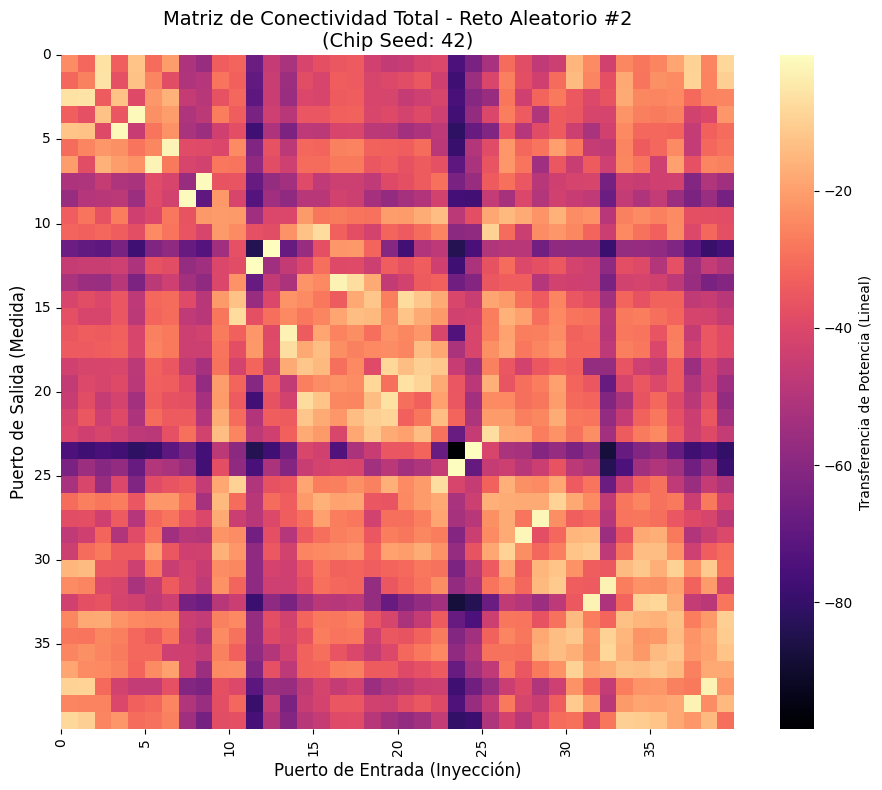

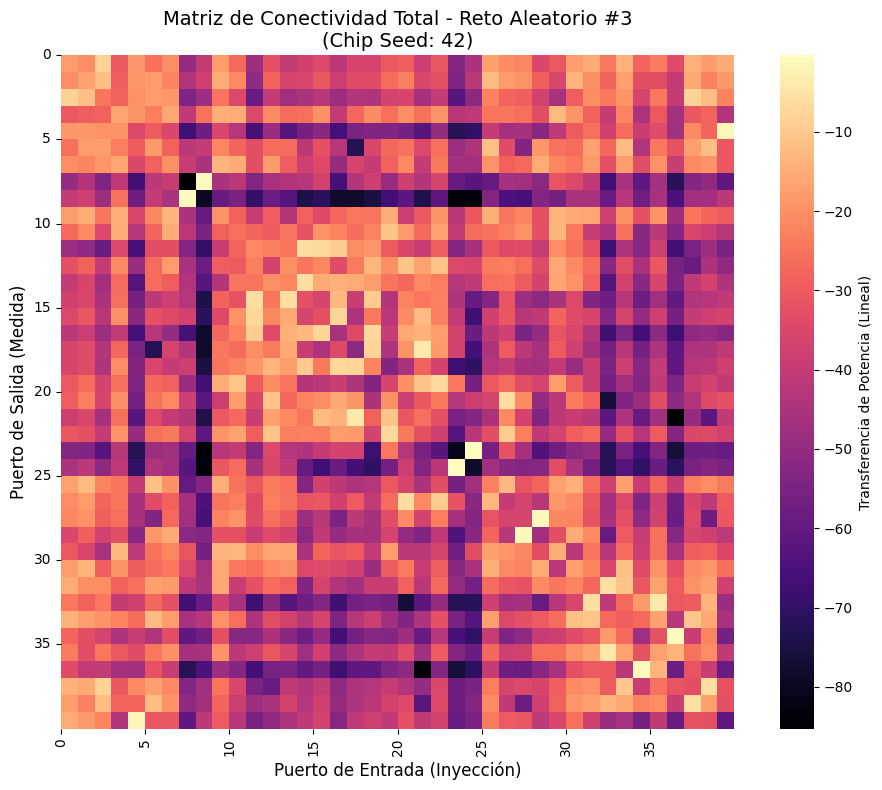

Se han generado 3 matrices de conectividad de 40x40.


In [55]:
# --- EXPERIMENTO: MATRIZ DE CONECTIVIDAD TOTAL (ALL-TO-ALL) ---

# 1. Parámetros fijos
seed_hardware = 42  # Un mismo chip físico
num_retos_a_graficar = 3 # Cuántos mapas de conectividad queremos ver
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]

# 2. Instanciamos el hardware una sola vez
malla_fija = malla_SNM_completa(tbus_columnas, ideal=False, seed=seed_hardware)
ids_ext = malla_fija.obtener_ids_perimetrales_ordenados()
num_puertos_ext = len(ids_ext)

# 3. Bucle para simular diferentes configuraciones (fases aleatorias)
for n in range(num_retos_a_graficar):
    # Generamos un reto aleatorio único para este "snapshot"
    reto = generar_configuracion_totalmente_aleatoria(malla_fija, seed=n*10)
    malla_fija.programar_malla(reto)
    
    # Calculamos la matriz S completa (40x40)
    # Internamente, resolver_matriz_total ya inyecta por cada puerto j 
    # y mide en cada puerto i 
    S_matriz = malla_fija.resolver_matriz_total(ids_ext)
    
   # potencia_matriz = np.abs(S_matriz)**2 # Convertimos a potencia lineal
    potencia_matriz = 10 * np.log10(np.abs(S_matriz)**2 + 1e-12)
    
    # 4. Graficamos la Matriz de Conectividad
    plt.figure(figsize=(10, 8))
    sns.heatmap(potencia_matriz, 
                cmap='magma', 
                square=True,
                cbar_kws={'label': 'Transferencia de Potencia (Lineal)'})
    
    plt.title(f"Matriz de Conectividad Total - Reto Aleatorio #{n+1}\n(Chip Seed: {seed_hardware})", fontsize=14)
    plt.xlabel("Puerto de Entrada (Inyección)", fontsize=12)
    plt.ylabel("Puerto de Salida (Medida)", fontsize=12)
    
    # Ajustamos los ticks para que se vean los 40 puertos
    plt.xticks(np.arange(0, num_puertos_ext, 5), np.arange(0, num_puertos_ext, 5))
    plt.yticks(np.arange(0, num_puertos_ext, 5), np.arange(0, num_puertos_ext, 5))
    
    plt.tight_layout()
    plt.show()

print(f"Se han generado {num_retos_a_graficar} matrices de conectividad de {num_puertos_ext}x{num_puertos_ext}.")

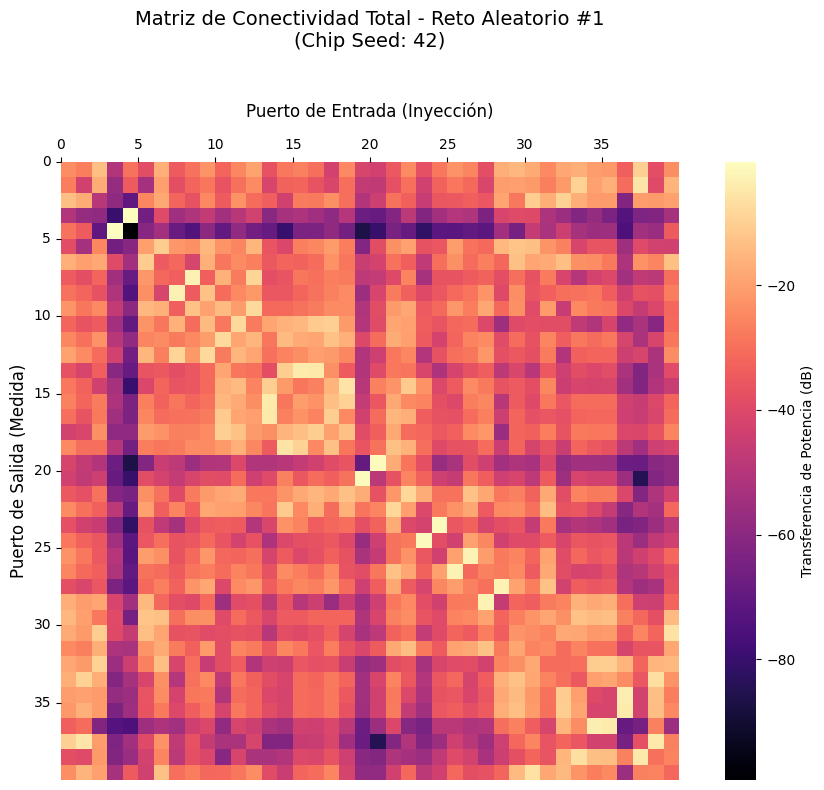

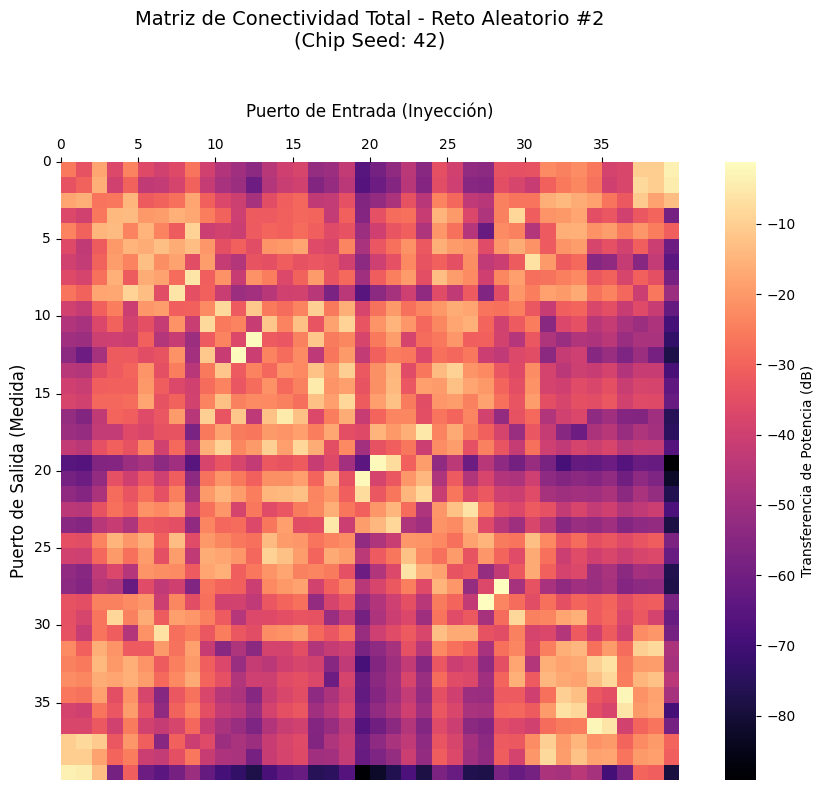

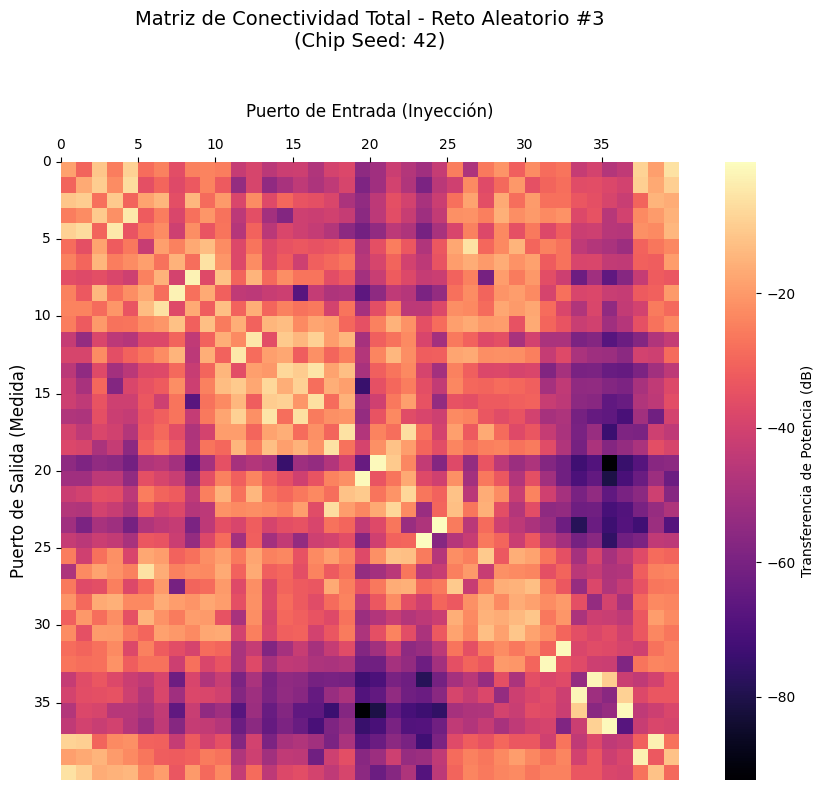

Se han generado 3 matrices de conectividad.


In [65]:
# --- EXPERIMENTO: MATRIZ DE CONECTIVIDAD TOTAL (ALL-TO-ALL) ---

# 1. Parámetros fijos
seed_hardware = 42  # Un mismo chip físico
num_retos_a_graficar = 3 
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]

# 2. Instanciamos el hardware una sola vez
malla_fija = malla_SNM_completa(tbus_columnas, ideal=False, seed=seed_hardware)
ids_ext = malla_fija.obtener_ids_perimetrales_ordenados()
num_puertos_ext = len(ids_ext)

# 3. Bucle para simular diferentes configuraciones (fases aleatorias)
for n in range(num_retos_a_graficar):
    # Generamos un reto aleatorio único
    reto = generar_configuracion_totalmente_aleatoria(malla_fija, seed=n*100)
    malla_fija.programar_malla(reto)
    
    # Calculamos la matriz S completa (40x40)
    S_matriz = malla_fija.resolver_matriz_total(ids_ext)
    
    # Transformación a dB para ver todo el rango dinámico
    potencia_matriz = 10 * np.log10(np.abs(S_matriz)**2 + 1e-12)
    
    # 4. Graficamos la Matriz de Conectividad
    plt.figure(figsize=(10, 8))
    
    # Asignamos el heatmap a la variable 'ax' para poder modificar los ejes
    ax = sns.heatmap(potencia_matriz, 
                cmap='magma', 
                square=True,
                cbar_kws={'label': 'Transferencia de Potencia (dB)'})
    
    # --- MOVER TICKS Y ETIQUETA AL TOP ---
    ax.xaxis.tick_top() # Mueve los ticks (números) a la parte superior
    ax.xaxis.set_label_position('top') # Mueve la etiqueta del eje a la parte superior
    
    # Ajustamos el título con un 'pad' mayor para que no se solape con el eje
    plt.title(f"Matriz de Conectividad Total - Reto Aleatorio #{n+1}\n(Chip Seed: {seed_hardware})", 
              fontsize=14, pad=40)
    
    plt.xlabel("Puerto de Entrada (Inyección)", fontsize=12, labelpad=15)
    plt.ylabel("Puerto de Salida (Medida)", fontsize=12)
    
    # Configuración de los intervalos de los ticks
    plt.xticks(np.arange(0, num_puertos_ext, 5), np.arange(0, num_puertos_ext, 5))
    plt.yticks(np.arange(0, num_puertos_ext, 5), np.arange(0, num_puertos_ext, 5))
    
    plt.tight_layout()
    plt.show()

print(f"Se han generado {num_retos_a_graficar} matrices de conectividad.")

Simulando 1000 matrices de conectividad total...
>> Progreso: 20/1000 retos completados
>> Progreso: 40/1000 retos completados
>> Progreso: 60/1000 retos completados
>> Progreso: 80/1000 retos completados
>> Progreso: 100/1000 retos completados
>> Progreso: 120/1000 retos completados
>> Progreso: 140/1000 retos completados
>> Progreso: 160/1000 retos completados
>> Progreso: 180/1000 retos completados
>> Progreso: 200/1000 retos completados
>> Progreso: 220/1000 retos completados
>> Progreso: 240/1000 retos completados
>> Progreso: 260/1000 retos completados
>> Progreso: 280/1000 retos completados
>> Progreso: 300/1000 retos completados
>> Progreso: 320/1000 retos completados
>> Progreso: 340/1000 retos completados
>> Progreso: 360/1000 retos completados
>> Progreso: 380/1000 retos completados
>> Progreso: 400/1000 retos completados
>> Progreso: 420/1000 retos completados
>> Progreso: 440/1000 retos completados
>> Progreso: 460/1000 retos completados
>> Progreso: 480/1000 retos complet

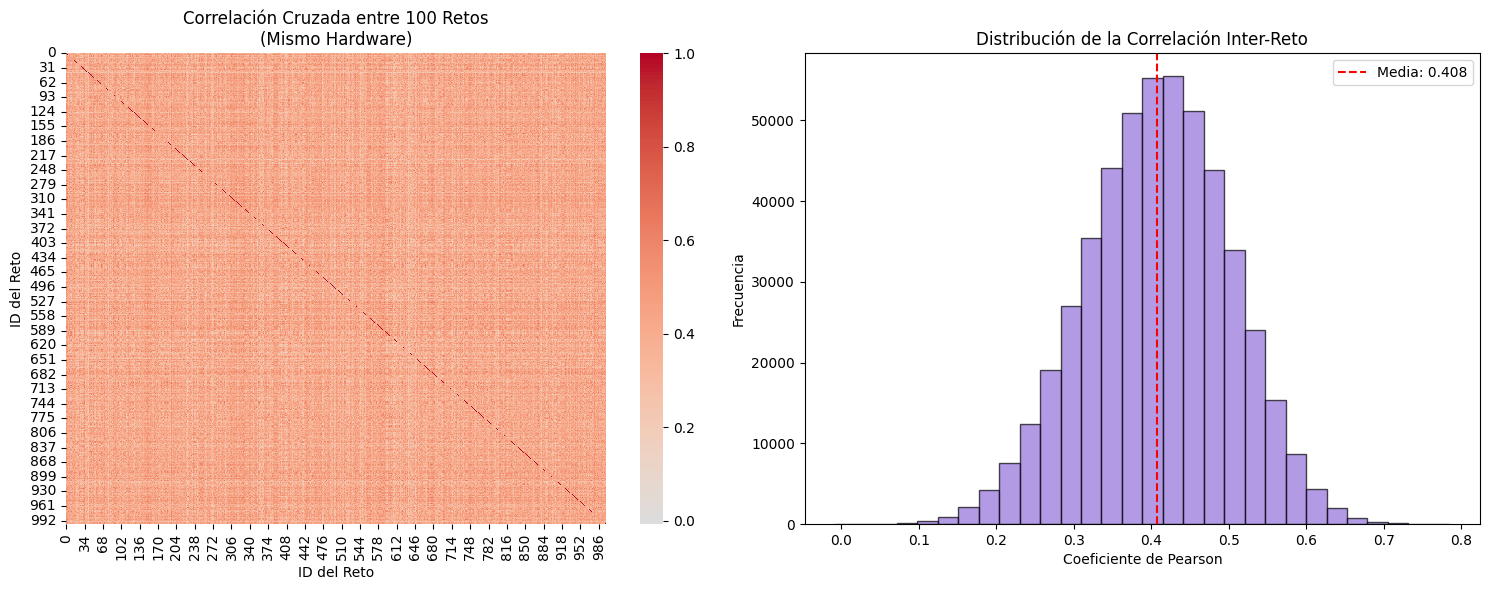

Análisis finalizado.
Similitud media entre configuraciones: 0.4080


In [81]:
# --- EXPERIMENTO: ANÁLISIS DE 100 MATRICES DE CONECTIVIDAD ---
# 1. Configuración
num_retos = 1000
seed_hardware = 42 
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]

# 2. Preparar el hardware
malla_fija = malla_SNM_completa(tbus_columnas, ideal=False, seed=seed_hardware)
ids_ext = malla_fija.obtener_ids_perimetrales_ordenados()
num_puertos = len(ids_ext)

print(f"Simulando {num_retos} matrices de conectividad total...")
matrices_aplanadas = []
potencias = []

# 3. Bucle de simulación
for n in range(num_retos):
    # Generar y programar reto
    reto = generar_configuracion_totalmente_aleatoria(malla_fija, seed=n)
    malla_fija.programar_malla(reto)
    
    # Obtener matriz S y convertir a potencia (dB)
    S_matriz = malla_fija.resolver_matriz_total(ids_ext)
    potencia_db = 10 * np.log10(np.abs(S_matriz)**2 + 1e-12)
    potencia_lineal = np.abs(S_matriz)**2
    
    # Aplanamos la matriz de 40x40 a un vector de 1600 para poder correlacionar
    matrices_aplanadas.append(potencia_db.flatten())
    
    potencias.append(potencia_lineal)
    if (n + 1) % 20 == 0:
        print(f">> Progreso: {n + 1}/{num_retos} retos completados")

# Convertimos a matriz de datos (100 retos x 1600 puntos de datos)
df_total = pd.DataFrame(np.array(matrices_aplanadas).T)

potencia_media = np.mean(potencias, axis = 0)
potencia_media_db = 10 * np.log10(potencia_media + 1e-12)

# 4. Cálculo de la Matriz de Correlación (100x100)
matriz_corr_retos = df_total.corr()
correlaciones_valores = matriz_corr_retos.values[np.triu_indices_from(matriz_corr_retos, k=1)]

# 5. Visualización de Resultados
plt.figure(figsize=(15, 6))

# A. Heatmap de Correlación entre Retos
plt.subplot(1, 2, 1)
sns.heatmap(matriz_corr_retos, cmap='coolwarm', center=0)
plt.title("Correlación Cruzada entre 100 Retos\n(Mismo Hardware)")
plt.xlabel("ID del Reto")
plt.ylabel("ID del Reto")

# B. Histograma de Correlaciones
plt.subplot(1, 2, 2)
plt.hist(correlaciones_valores, bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(correlaciones_valores), color='red', linestyle='--', 
            label=f'Media: {np.mean(correlaciones_valores):.3f}')
plt.title("Distribución de la Correlación Inter-Reto")
plt.xlabel("Coeficiente de Pearson")
plt.ylabel("Frecuencia")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Análisis finalizado.")
print(f"Similitud media entre configuraciones: {np.mean(correlaciones_valores):.4f}")

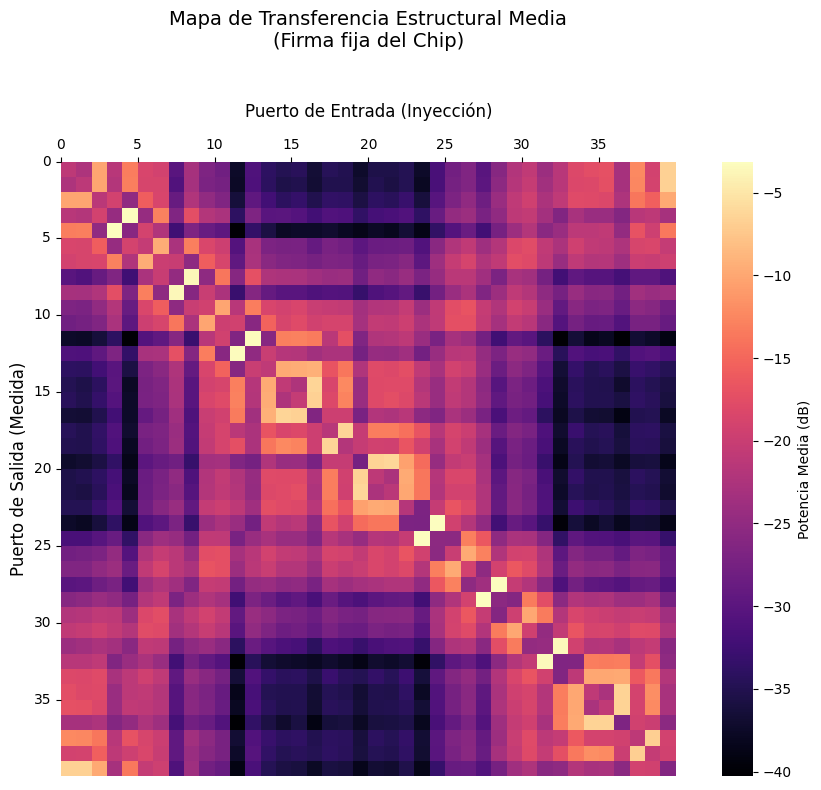

In [82]:
# 3. Graficamos
plt.figure(figsize=(10, 8))
ax = sns.heatmap(potencia_media_db, 
                 cmap='magma', 
                 square=True, 
                 cbar_kws={'label': 'Potencia Media (dB)'})

# Configuramos los ejes para que el de entrada esté arriba (como pediste antes)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.title("Mapa de Transferencia Estructural Media\n(Firma fija del Chip)", fontsize=14, pad=40)
plt.xlabel("Puerto de Entrada (Inyección)", fontsize=12, labelpad=15)
plt.ylabel("Puerto de Salida (Medida)", fontsize=12)

# Ticks cada 5 puertos para claridad
plt.xticks(np.arange(0, num_puertos, 5), np.arange(0, num_puertos, 5))
plt.yticks(np.arange(0, num_puertos, 5), np.arange(0, num_puertos, 5))

plt.tight_layout()
plt.show()

In [83]:
potencia_media_db_1000 = potencia_media_db

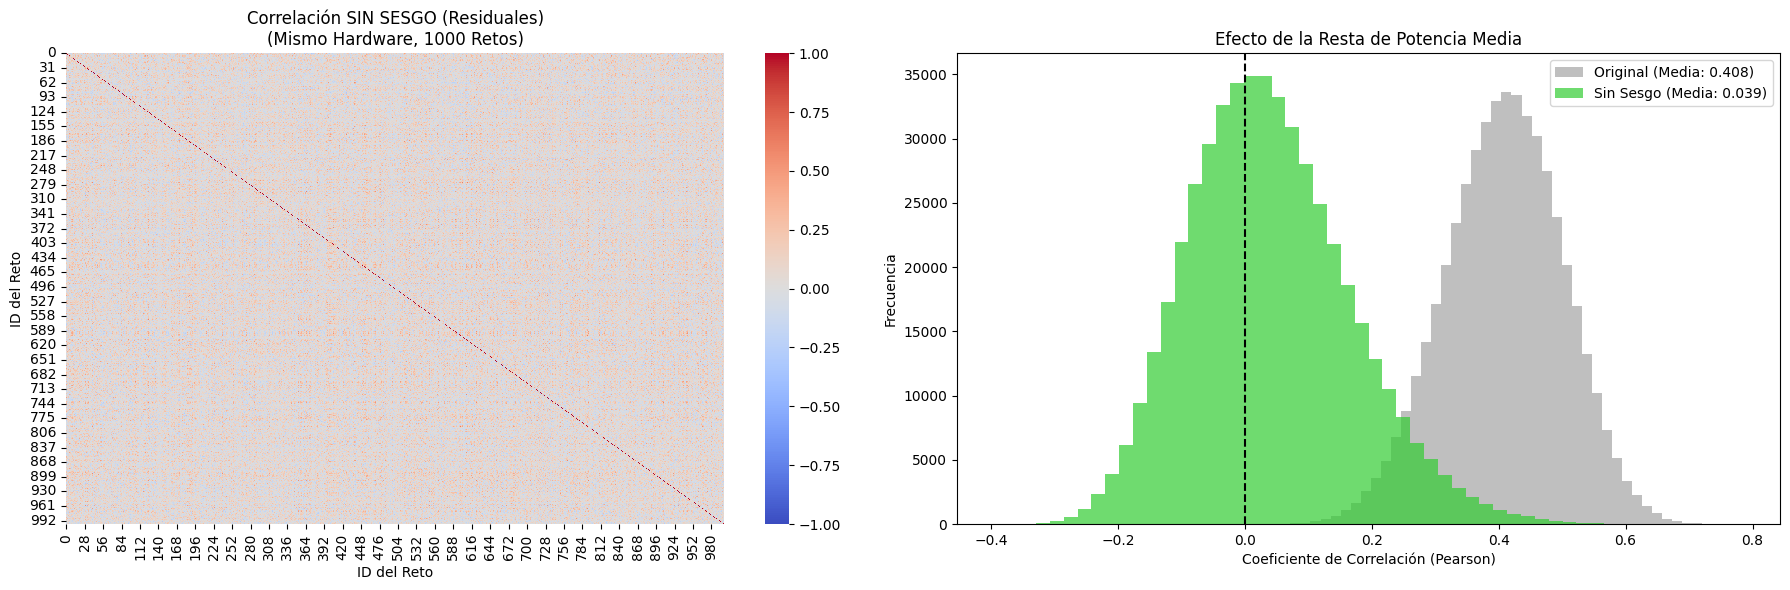

--- RESULTADOS DEL BLANQUEO ---
Correlación media original: 0.4080
Correlación media tras restar la media: 0.0390


In [85]:
# --- EXPERIMENTO: ELIMINACIÓN DEL SESGO ESTRUCTURAL (WHITENING) ---

# 1. Aplanamos la potencia media en dB para que coincida con el formato de las otras matrices
potencia_media_db_flatten = potencia_media_db_1000.flatten()

# 2. Restamos la media a cada una de las 1000 simulaciones
# Al estar en dB, restar la media equivale a normalizar la potencia estructural
matrices_sin_sesgo = [m - potencia_media_db_flatten for m in matrices_aplanadas]

# 3. Creamos un nuevo DataFrame con los datos "limpios"
df_sin_sesgo = pd.DataFrame(np.array(matrices_sin_sesgo).T)

# 4. Calculamos la nueva Matriz de Correlación
matriz_corr_sin_sesgo = df_sin_sesgo.corr()
correlaciones_sin_sesgo = matriz_corr_sin_sesgo.values[np.triu_indices_from(matriz_corr_sin_sesgo, k=1)]

# 5. Visualización Comparativa
plt.figure(figsize=(18, 6))

# A. Nuevo Heatmap (debería verse mucho más azul/frío, indicando menos correlación)
plt.subplot(1, 2, 1)
sns.heatmap(matriz_corr_sin_sesgo, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Correlación SIN SESGO (Residuales)\n(Mismo Hardware, 1000 Retos)")
plt.xlabel("ID del Reto")
plt.ylabel("ID del Reto")

# B. Comparación de Histogramas (Antes vs Después)
plt.subplot(1, 2, 2)
plt.hist(correlaciones_valores, bins=50, color='gray', alpha=0.5, label=f'Original (Media: {np.mean(correlaciones_valores):.3f})')
plt.hist(correlaciones_sin_sesgo, bins=50, color='limegreen', alpha=0.7, label=f'Sin Sesgo (Media: {np.mean(correlaciones_sin_sesgo):.3f})')
plt.axvline(0, color='black', linestyle='--')
plt.title("Efecto de la Resta de Potencia Media")
plt.xlabel("Coeficiente de Correlación (Pearson)")
plt.ylabel("Frecuencia")
plt.legend()

plt.tight_layout()
plt.show()

print(f"--- RESULTADOS DEL BLANQUEO ---")
print(f"Correlación media original: {np.mean(correlaciones_valores):.4f}")
print(f"Correlación media tras restar la media: {np.mean(correlaciones_sin_sesgo):.4f}")

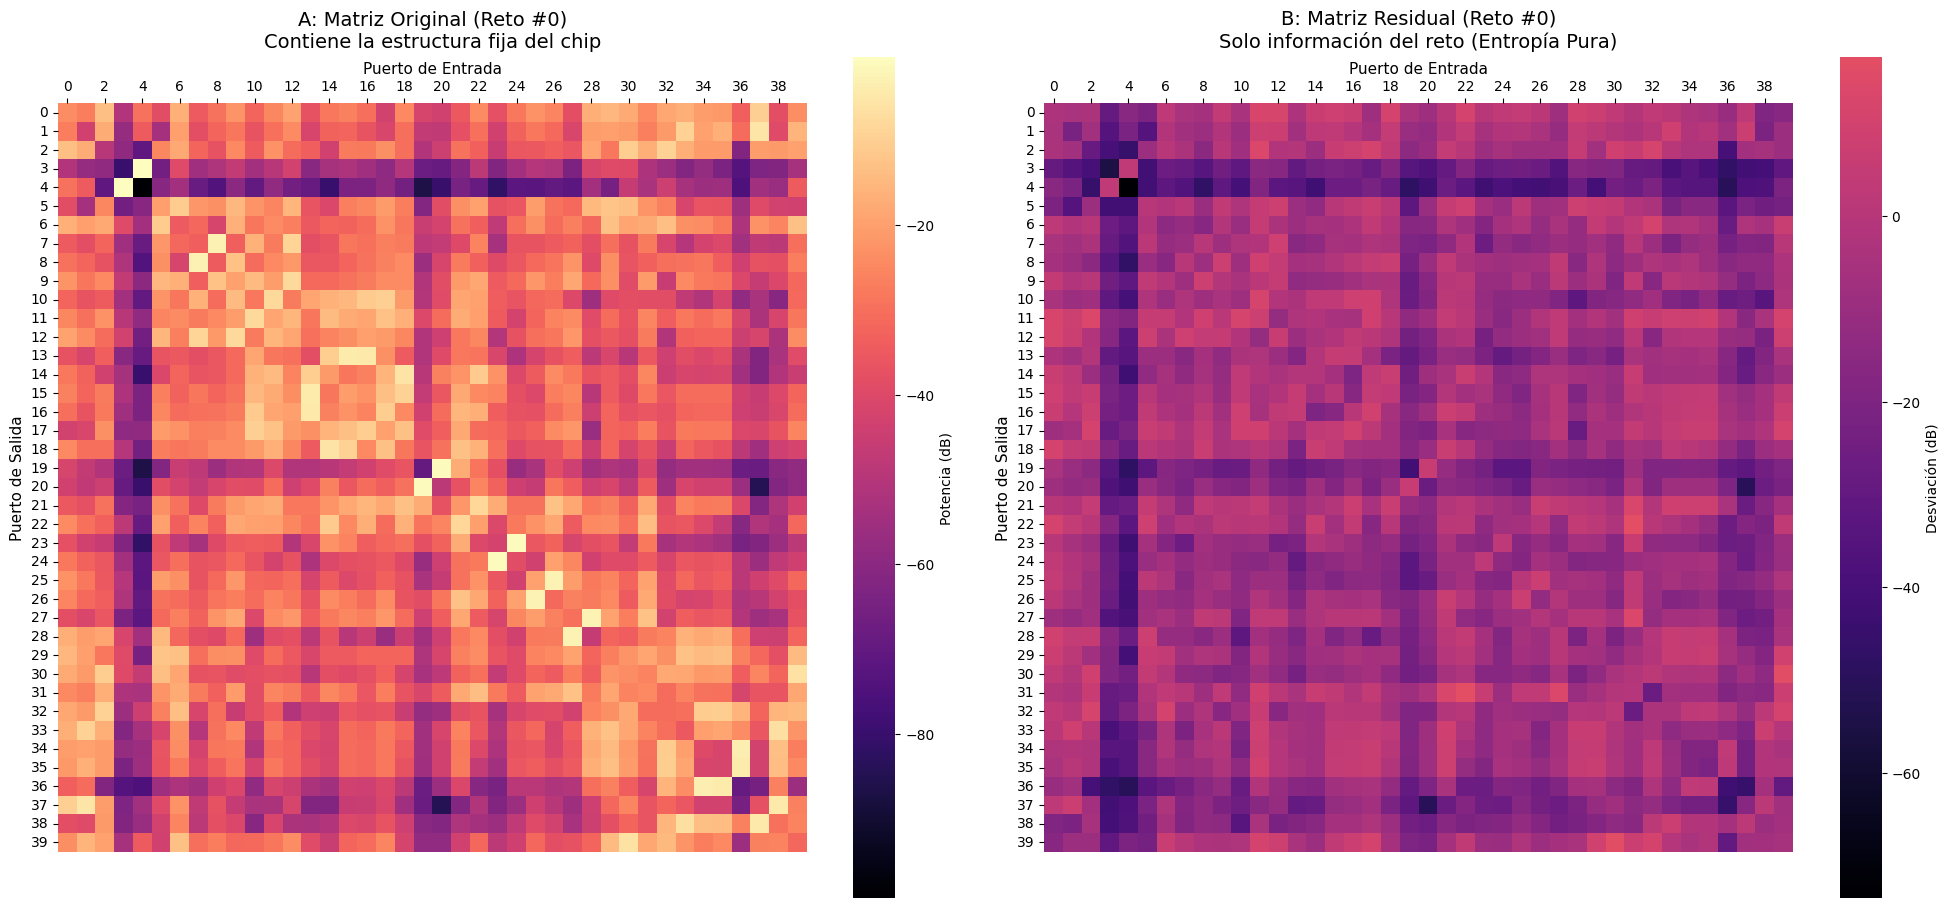

La matriz A tiene una correlación media inter-reto de 0.4080
La matriz B tiene una correlación media inter-reto de 0.0390


In [91]:
# --- COMPARATIVA: MATRIZ ORIGINAL VS MATRIZ SIN SESGO ---

# 1. Elegimos el reto (n=0)
n_reto = 0 

# 2. Re-dimensionamos ambas matrices a 40x40
matriz_original_db = matrices_aplanadas[n_reto].reshape(num_puertos, num_puertos)
matriz_residual_db = matrices_sin_sesgo[n_reto].reshape(num_puertos, num_puertos)

# 3. Creamos la figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# --- GRÁFICA 1: MATRIZ ORIGINAL (CON SESGO) ---
sns.heatmap(matriz_original_db, cmap='magma', ax=ax1, square=True,
            cbar_kws={'label': 'Potencia (dB)'})
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position('top')
ax1.set_title(f"A: Matriz Original (Reto #{n_reto})\nContiene la estructura fija del chip", 
              fontsize=14, pad=40)
ax1.set_xlabel("Puerto de Entrada", fontsize=11)
ax1.set_ylabel("Puerto de Salida", fontsize=11)

# --- GRÁFICA 2: MATRIZ RESIDUAL (SIN SESGO) ---
# Usamos 'RdBu_r' porque es una matriz divergente (valores centrados en 0)
sns.heatmap(matriz_residual_db, cmap='magma', center=0, ax=ax2, square=True,
            cbar_kws={'label': 'Desviación (dB)'})
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position('top')
ax2.set_title(f"B: Matriz Residual (Reto #{n_reto})\nSolo información del reto (Entropía Pura)", 
              fontsize=14, pad=40)
ax2.set_xlabel("Puerto de Entrada", fontsize=11)
ax2.set_ylabel("Puerto de Salida", fontsize=11)

plt.tight_layout()
plt.show()

print(f"La matriz A tiene una correlación media inter-reto de 0.4080")
print(f"La matriz B tiene una correlación media inter-reto de 0.0390")

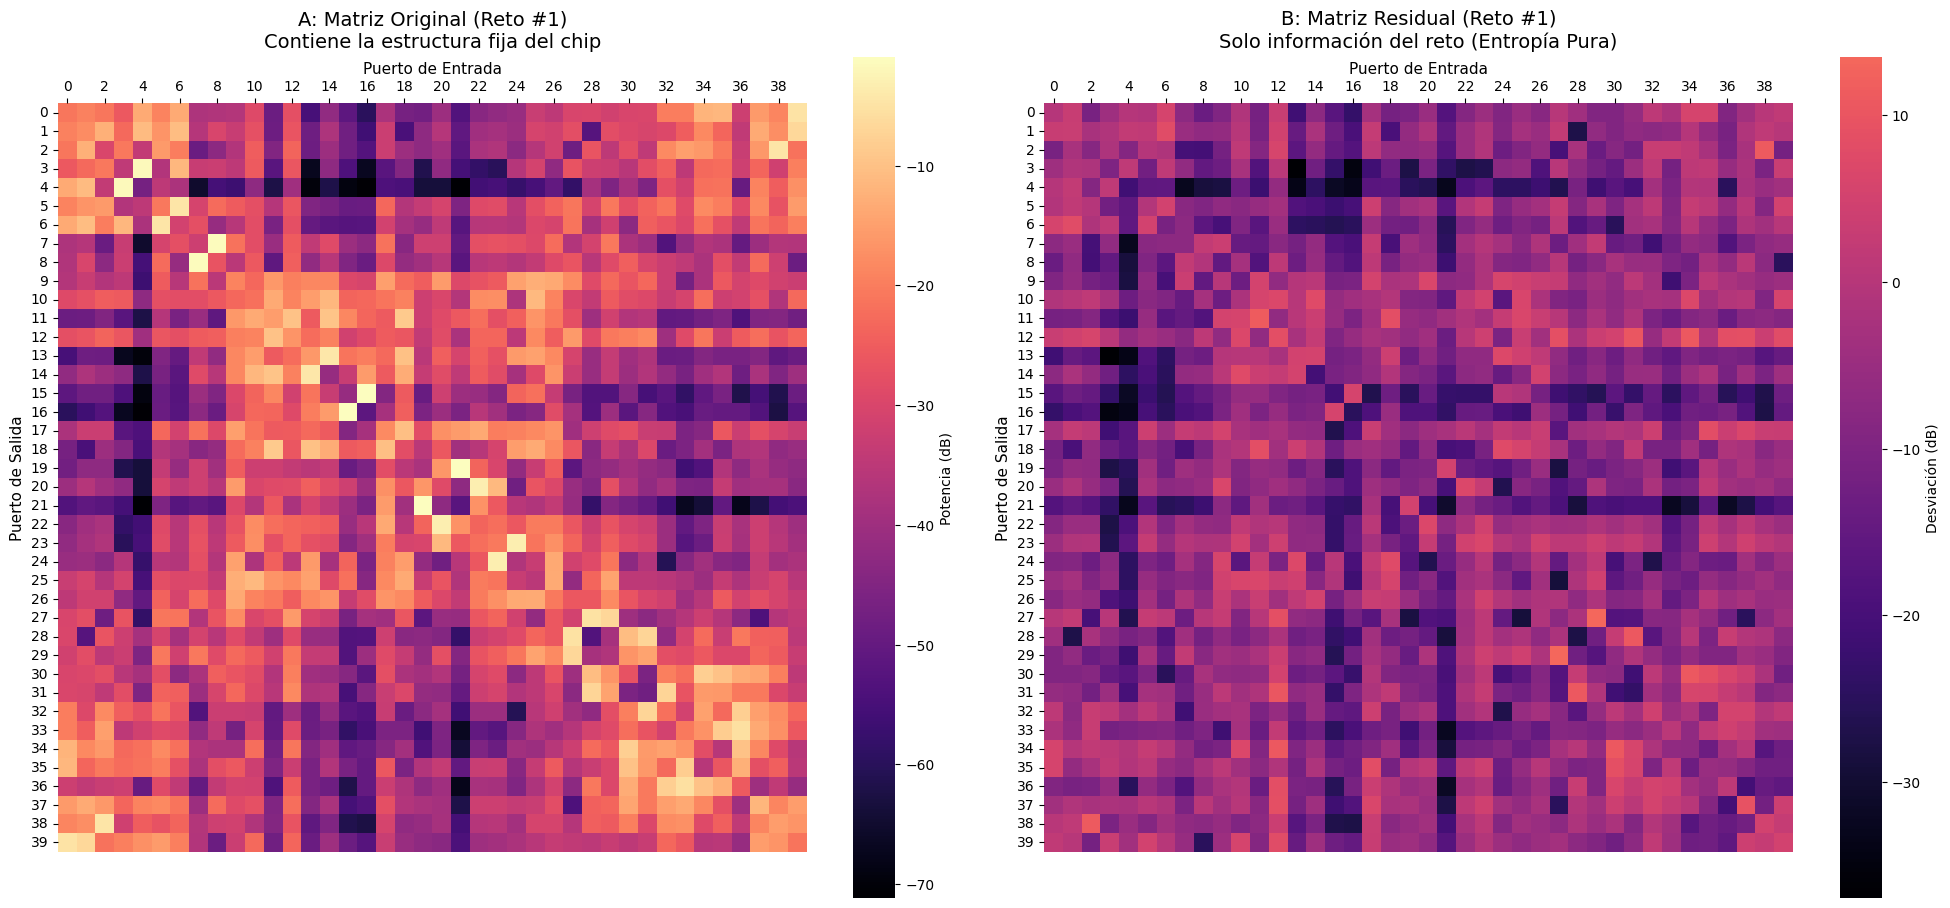

La matriz A tiene una correlación media inter-reto de 0.4080
La matriz B tiene una correlación media inter-reto de 0.0390


In [92]:
# --- COMPARATIVA: MATRIZ ORIGINAL VS MATRIZ SIN SESGO ---

# 1. Elegimos el reto (n=0)
n_reto = 1

# 2. Re-dimensionamos ambas matrices a 40x40
matriz_original_db = matrices_aplanadas[n_reto].reshape(num_puertos, num_puertos)
matriz_residual_db = matrices_sin_sesgo[n_reto].reshape(num_puertos, num_puertos)

# 3. Creamos la figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# --- GRÁFICA 1: MATRIZ ORIGINAL (CON SESGO) ---
sns.heatmap(matriz_original_db, cmap='magma', ax=ax1, square=True,
            cbar_kws={'label': 'Potencia (dB)'})
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position('top')
ax1.set_title(f"A: Matriz Original (Reto #{n_reto})\nContiene la estructura fija del chip", 
              fontsize=14, pad=40)
ax1.set_xlabel("Puerto de Entrada", fontsize=11)
ax1.set_ylabel("Puerto de Salida", fontsize=11)

# --- GRÁFICA 2: MATRIZ RESIDUAL (SIN SESGO) ---
# Usamos 'RdBu_r' porque es una matriz divergente (valores centrados en 0)
sns.heatmap(matriz_residual_db, cmap='magma', center=0, ax=ax2, square=True,
            cbar_kws={'label': 'Desviación (dB)'})
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position('top')
ax2.set_title(f"B: Matriz Residual (Reto #{n_reto})\nSolo información del reto (Entropía Pura)", 
              fontsize=14, pad=40)
ax2.set_xlabel("Puerto de Entrada", fontsize=11)
ax2.set_ylabel("Puerto de Salida", fontsize=11)

plt.tight_layout()
plt.show()

print(f"La matriz A tiene una correlación media inter-reto de 0.4080")
print(f"La matriz B tiene una correlación media inter-reto de 0.0390")

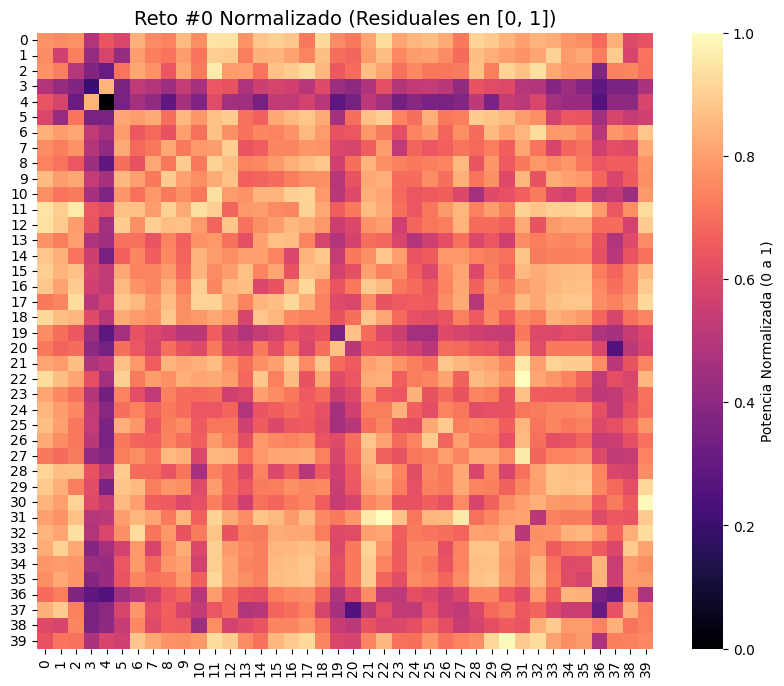

Rango de la matriz: [0.00, 1.00]


In [94]:
# --- EXPERIMENTO: NORMALIZACIÓN DE RESIDUALES ---

# 1. Función para normalizar una matriz entre 0 y 1
def normalizar_min_max(matriz):
    m_min = np.min(matriz)
    m_max = np.max(matriz)
    return (matriz - m_min) / (m_max - m_min)

# 2. Aplicamos la normalización a todos nuestros retos "sin sesgo"
matrices_norm = [normalizar_min_max(m) for m in matrices_sin_sesgo]

# 3. Visualizamos el resultado del mismo reto (n=0)
n_reto = 0
matriz_plot = matrices_norm[n_reto].reshape(num_puertos, num_puertos)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_plot, cmap='magma', square=True, vmin=0, vmax=1,
            cbar_kws={'label': 'Potencia Normalizada (0 a 1)'})

plt.title(f"Reto #{n_reto} Normalizado (Residuales en [0, 1])", fontsize=14)
plt.show()

print(f"Rango de la matriz: [{np.min(matriz_plot):.2f}, {np.max(matriz_plot):.2f}]")

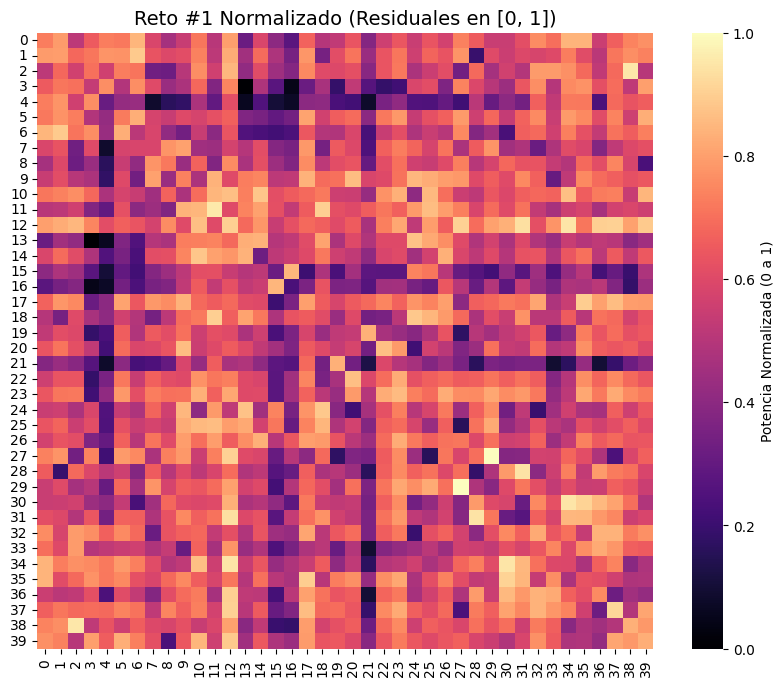

Rango de la matriz: [0.00, 1.00]


In [95]:
# 3. Visualizamos el resultado del mismo reto (n=0)
n_reto = 1
matriz_plot = matrices_norm[n_reto].reshape(num_puertos, num_puertos)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_plot, cmap='magma', square=True, vmin=0, vmax=1,
            cbar_kws={'label': 'Potencia Normalizada (0 a 1)'})

plt.title(f"Reto #{n_reto} Normalizado (Residuales en [0, 1])", fontsize=14)
plt.show()

print(f"Rango de la matriz: [{np.min(matriz_plot):.2f}, {np.max(matriz_plot):.2f}]")

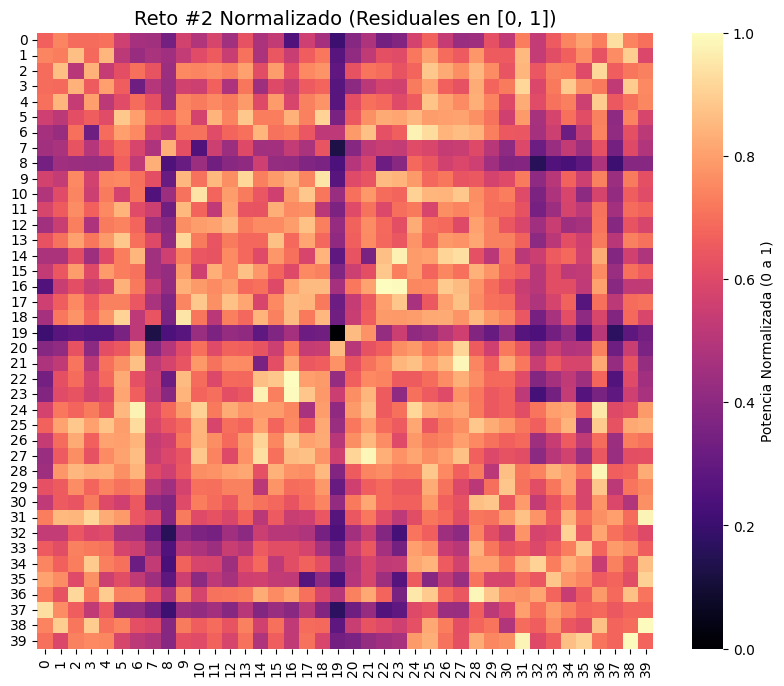

Rango de la matriz: [0.00, 1.00]


In [97]:
# 3. Visualizamos el resultado del mismo reto (n=0)
n_reto = 2
matriz_plot = matrices_norm[n_reto].reshape(num_puertos, num_puertos)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_plot, cmap='magma', square=True, vmin=0, vmax=1,
            cbar_kws={'label': 'Potencia Normalizada (0 a 1)'})

plt.title(f"Reto #{n_reto} Normalizado (Residuales en [0, 1])", fontsize=14)
plt.show()

print(f"Rango de la matriz: [{np.min(matriz_plot):.2f}, {np.max(matriz_plot):.2f}]")

In [98]:
import os
# GUARDAR DATOS
matrices_sin_sesgo_array = np.array([m.reshape(num_puertos, num_puertos) for m in matrices_sin_sesgo])
matrices_norm_array = np.array([m.reshape(num_puertos, num_puertos) for m in matrices_norm])

np.savez_compressed(
    'puf_dataset_final.npz', 
    potencias_lineales = np.array(potencias),    # Potencias originales (lineal)
    media_db = potencia_media_db,                # Firma estructural (la media)
    originales_db = np.array(matrices_aplanadas).reshape(-1, num_puertos, num_puertos),
    sin_sesgo_db = matrices_sin_sesgo_array,     # Residuales (Blanqueadas)
    normalizadas = matrices_norm_array,          # Rango [0, 1]
    config = tbus_columnas,                      # Tu malla de 40 puertos
    num_retos = num_retos
)

print("¡Archivo 'puf_dataset_final.npz' guardado con éxito!")
print(f"Peso aproximado del archivo: {os.path.getsize('puf_dataset_final.npz') / 1e6:.2f} MB")

¡Archivo 'puf_dataset_final.npz' guardado con éxito!


NameError: name 'os' is not defined

In [ ]:
# DESCARGAR DATOS

data = np.load('puf_dataset_final.npz')

# Extraer cada matriz
potencias = data['potencias_lineales']
potencia_media_db = data['media_db']
matrices_sin_sesgo = data['sin_sesgo_db']
matrices_norm = data['normalizadas']
tbus_columnas = data['config']

print(f"Datos cargados: {len(matrices_sin_sesgo)} retos listos para procesar.")

In [125]:
import numpy as np
import hashlib
import bchlib
import math

# --- TUS FUNCIONES ORIGINALES (Mantener igual) ---

def binarización(valores):
    valores = list(valores)
    n = len(valores)
    r = []
    for j in range(1, n): 
        cuenta = 0
        for i in range(j):  
            if valores[j] > valores[i]:
                cuenta += 1
        r.append(cuenta)
    def a_gray(x):
        return x ^ (x >> 1)
    bloques_gray = []
    for j in range(1, len(r) + 1):    
        rj = r[j-1]  
        bits = math.ceil(math.log2(j + 1))       
        gj = a_gray(rj)
        bloques_gray.append(format(gj, f"0{bits}b")) 
    return "".join(bloques_gray), r, bloques_gray

def string_a_bits(respuesta):
    return [int(c) for c in respuesta]

def rellenar_a_byte(bits):
    resto = len(bits) % 8
    if resto != 0:
        bits += [1] * (8 - resto)
    return bits

def bits_to_bytes_local(bits):
    out = bytearray()
    for i in range(0, len(bits), 8):
        byte = 0
        for bit in bits[i:i+8]:
            byte = (byte << 1) | bit
        out.append(byte)
    return bytes(out)

def bytes_to_bits(data):
    out = []
    for byte in data:
        for i in range(7, -1, -1):
            out.append((byte >> i) & 1)
    return out

def xor_bits(a, b):
    return [x ^ y for x, y in zip(a, b)]

def hamming_distance(a, b):
    diff = xor_bits(a, b)
    return sum(diff)

# --- NUEVAS FUNCIONES PARA EL FUZZY EXTRACTOR Y BCH ---

def puf_enrollment(bits, bch_obj, n_bloques=64):
    """Genera la paridad (Helper Data) para una huella original."""
    fragmentos = np.array_split(bits, n_bloques)
    helper_data_list = []
    for frag in fragmentos:
        data_bytes = bits_to_bytes_local(rellenar_a_byte(list(frag)))
        paridad = bch_obj.encode(data_bytes)
        helper_data_list.append(paridad)
    return helper_data_list

def puf_reconstruction(bits_ruidosos, helper_data_list, bch_obj):
    """Corrige errores en una huella ruidosa usando el Helper Data."""
    n_bloques = len(helper_data_list)
    fragmentos = np.array_split(bits_ruidosos, n_bloques)
    bloques_corregidos = []
    errores_totales = 0
    
    for i in range(n_bloques):
        data_r = bytearray(bits_to_bytes_local(rellenar_a_byte(list(fragmentos[i]))))
        paridad = bytearray(helper_data_list[i])
        
        n_err = bch_obj.decode(data_r, paridad)
        if n_err >= 0:
            bch_obj.correct(data_r, paridad)
            errores_totales += n_err
        bloques_corregidos.append(data_r)
        
    return b"".join(bloques_corregidos), errores_totales

def generar_hash_sha256(datos_bytes):
    """Genera el hash final en formato hexadecimal."""
    return hashlib.sha256(datos_bytes).hexdigest()
# --- 2. PROCESAMIENTO DE LA HUELLA COMPLETA (1600 PUNTOS) ---

# Usamos el primer reto (n=0) de tus matrices sin sesgo
n_reto = 0
huella_analogica = matrices_sin_sesgo[n_reto].flatten()

print(f"Calculando coeficientes de Lehmer para {len(huella_analogica)} puntos...")
print("(Esto puede tardar unos segundos debido a la complejidad del algoritmo...)")

# Ejecutamos la binarización
bits_string, coef_r, bloques = binarización(huella_analogica)
r_puf_completa = string_a_bits(bits_string)
r_puf_completa = rellenar_a_byte(r_puf_completa)

# --- 3. ANÁLISIS DE LA LLAVE EXTRAÍDA ---

L_total = len(r_puf_completa)
print(f"\n--- RESULTADOS ---")
print(f"Longitud final de la cadena de bits: {L_total} bits")
print(f"Equivale a {L_total // 8} bytes de información pura.")

# Generamos el Hash SHA-256 final (La Llave Maestra)
# La función bits_to_bytes es necesaria para el hash
def bits_to_bytes_local(bits):
    out = bytearray()
    for i in range(0, len(bits), 8):
        byte = 0
        for bit in bits[i:i+8]:
            byte = (byte << 1) | bit
        out.append(byte)
    return bytes(out)

llave_maestra = hashlib.sha256(bits_to_bytes_local(r_puf_completa)).hexdigest()

print(f"\nLlave Maestra (SHA-256) del Reto #{n_reto}:")
print(f"{llave_maestra}")

Calculando coeficientes de Lehmer para 1600 puntos...
(Esto puede tardar unos segundos debido a la complejidad del algoritmo...)

--- RESULTADOS ---
Longitud final de la cadena de bits: 15560 bits
Equivale a 1945 bytes de información pura.

Llave Maestra (SHA-256) del Reto #0:
d2ad428434380628253aa4d9b1a315231ffe259d3ce6b616f88913558639f3d5


In [126]:
# Usamos el primer reto (n=0) de tus matrices sin sesgo
n_reto = 2
huella_analogica = matrices_sin_sesgo[n_reto].flatten()

print(f"Calculando coeficientes de Lehmer para {len(huella_analogica)} puntos...")
print("(Esto puede tardar unos segundos debido a la complejidad del algoritmo...)")

# Ejecutamos la binarización
bits_string, coef_r, bloques = binarización(huella_analogica)
r_puf_completa = string_a_bits(bits_string)
r_puf_completa = rellenar_a_byte(r_puf_completa)

# --- 3. ANÁLISIS DE LA LLAVE EXTRAÍDA ---

L_total = len(r_puf_completa)
print(f"\n--- RESULTADOS ---")
print(f"Longitud final de la cadena de bits: {L_total} bits")
print(f"Equivale a {L_total // 8} bytes de información pura.")

# Generamos el Hash SHA-256 final (La Llave Maestra)
# La función bits_to_bytes es necesaria para el hash
def bits_to_bytes_local(bits):
    out = bytearray()
    for i in range(0, len(bits), 8):
        byte = 0
        for bit in bits[i:i+8]:
            byte = (byte << 1) | bit
        out.append(byte)
    return bytes(out)

llave_maestra = hashlib.sha256(bits_to_bytes_local(r_puf_completa)).hexdigest()

print(f"\nLlave Maestra (SHA-256) del Reto #{n_reto}:")
print(f"{llave_maestra}")

Calculando coeficientes de Lehmer para 1600 puntos...
(Esto puede tardar unos segundos debido a la complejidad del algoritmo...)

--- RESULTADOS ---
Longitud final de la cadena de bits: 15560 bits
Equivale a 1945 bytes de información pura.

Llave Maestra (SHA-256) del Reto #2:
277d491971cfa0350c34393f36299613bb05b7b3d8fddf801cdef0ffbb1ef2fe


In [127]:


# --- CONFIGURACIÓN DEL ANÁLISIS ---
n_analisis = 100  
llaves_binarias = []
llaves_hex = []

print(f"Generando llaves maestras para {n_analisis} retos...")

for i in range(n_analisis):
    # 1. Extraer huella de 1600 puntos
    huella = matrices_sin_sesgo[i].flatten()
    
    # 2. Binarización de Lehmer
    bits_str, _, _ = binarización(huella)
    bits = string_a_bits(bits_str)
    bits = rellenar_a_byte(bits)
    
    # 3. Hashing SHA-256
    bytes_puf = bits_to_bytes_local(bits)
    hash_obj = hashlib.sha256(bytes_puf)
    
    llaves_binarias.append(bytes_to_bits(hash_obj.digest()))
    llaves_hex.append(hash_obj.hexdigest())
    print(f" -> Llave #{i} generada con éxito.")

# --- CÁLCULO DE LA MATRIZ DE DISTANCIA DE HAMMING ---
distancias = np.zeros((n_analisis, n_analisis))

for i in range(n_analisis):
    for j in range(n_analisis):
        # Distancia de Hamming normalizada (0 a 1)
        # 0.5 significa que la mitad de los bits son diferentes (IDEAL)
        distancias[i, j] = hamming_distance(llaves_binarias[i], llaves_binarias[j]) / 256

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 8))
sns.heatmap(distancias, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Distancia de Hamming Normalizada'})
plt.title("Matriz de Unicidad (Inter-Challenge)\nDistancia entre Llaves SHA-256 de 256 bits", fontsize=14, pad=20)
plt.xlabel("ID del Reto")
plt.ylabel("ID del Reto")
plt.show()

# Resumen estadístico
valores_tri = distancias[np.triu_indices(n_analisis, k=1)]
print(f"\n--- ESTADÍSTICAS DE UNICIDAD ---")
print(f"Distancia de Hamming Media: {np.mean(valores_tri):.4f} (Ideal: 0.5000)")
print(f"Desviación Estándar: {np.std(valores_tri):.4f}")

Generando llaves maestras para 100 retos...
 -> Llave #0 generada con éxito.
 -> Llave #1 generada con éxito.
 -> Llave #2 generada con éxito.
 -> Llave #3 generada con éxito.
 -> Llave #4 generada con éxito.
 -> Llave #5 generada con éxito.
 -> Llave #6 generada con éxito.
 -> Llave #7 generada con éxito.
 -> Llave #8 generada con éxito.
 -> Llave #9 generada con éxito.
 -> Llave #10 generada con éxito.
 -> Llave #11 generada con éxito.
 -> Llave #12 generada con éxito.
 -> Llave #13 generada con éxito.
 -> Llave #14 generada con éxito.
 -> Llave #15 generada con éxito.
 -> Llave #16 generada con éxito.
 -> Llave #17 generada con éxito.
 -> Llave #18 generada con éxito.
 -> Llave #19 generada con éxito.
 -> Llave #20 generada con éxito.
 -> Llave #21 generada con éxito.
 -> Llave #22 generada con éxito.
 -> Llave #23 generada con éxito.
 -> Llave #24 generada con éxito.
 -> Llave #25 generada con éxito.
 -> Llave #26 generada con éxito.
 -> Llave #27 generada con éxito.
 -> Llave #28 

KeyboardInterrupt: 

Analizando la uniformidad de los bits crudos para 100 retos...
(Este proceso evalúa la calidad pura de tu hardware)
 -> 20/100 retos procesados...
 -> 40/100 retos procesados...
 -> 60/100 retos procesados...
 -> 80/100 retos procesados...
 -> 100/100 retos procesados...


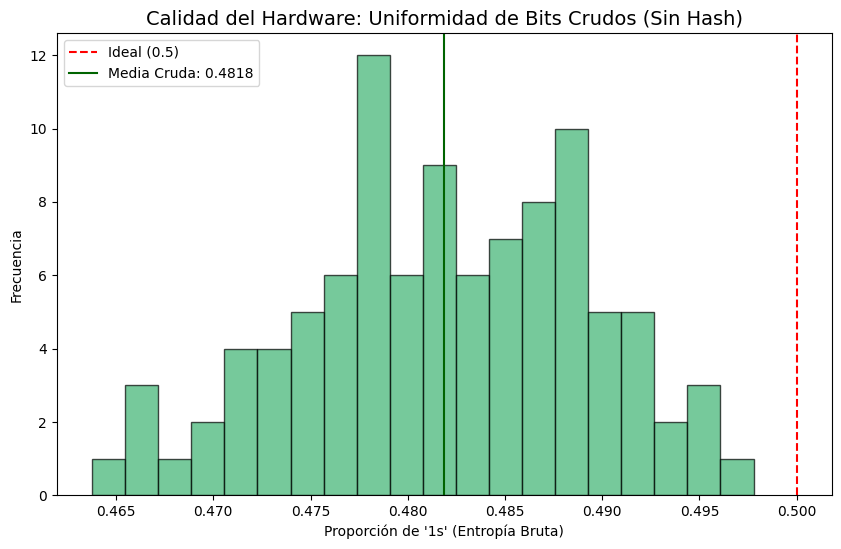

--- RESULTADOS DE HARDWARE ---
Uniformidad Media Cruda: 0.4818
Desviación Estándar: 0.0073

CONCLUSIÓN: Existe un ligero sesgo en el hardware.


In [128]:
# --- MÉTRICA: UNIFORMIDAD DE BITS CRUDOS (ANTES DEL HASH) ---

uniformidades_crudas = []

print(f"Analizando la uniformidad de los bits crudos para 100 retos...")
print("(Este proceso evalúa la calidad pura de tu hardware)")

for i in range(100):
    # 1. Obtener huella de 1600 puntos
    huella = matrices_sin_sesgo[i].flatten()
    
    # 2. Binarización de Lehmer (obtenemos los 15,560 bits)
    bits_str, _, _ = binarización(huella)
    bits_raw = string_a_bits(bits_str) # No hace falta rellenar a byte para este test
    
    # 3. Calcular proporción de 1s en esta cadena
    u_i = sum(bits_raw) / len(bits_raw)
    uniformidades_crudas.append(u_i)
    
    if (i+1) % 20 == 0:
        print(f" -> {i+1}/100 retos procesados...")

# --- ESTADÍSTICAS Y VISUALIZACIÓN ---
u_media_raw = np.mean(uniformidades_crudas)

plt.figure(figsize=(10, 6))
plt.hist(uniformidades_crudas, bins=20, color='mediumseagreen', edgecolor='black', alpha=0.7)
plt.axvline(0.5, color='red', linestyle='--', label='Ideal (0.5)')
plt.axvline(u_media_raw, color='darkgreen', linestyle='-', label=f'Media Cruda: {u_media_raw:.4f}')

plt.title("Calidad del Hardware: Uniformidad de Bits Crudos (Sin Hash)", fontsize=14)
plt.xlabel("Proporción de '1s' (Entropía Bruta)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

print(f"--- RESULTADOS DE HARDWARE ---")
print(f"Uniformidad Media Cruda: {u_media_raw:.4f}")
print(f"Desviación Estándar: {np.std(uniformidades_crudas):.4f}")

if 0.49 <= u_media_raw <= 0.51:
    print("\nCONCLUSIÓN: Tu hardware y el proceso de blanqueo son EXCELENTES.")
    print("La fuente de datos es simétrica y no tiene sesgo hacia ningún valor.")
else:
    print("\nCONCLUSIÓN: Existe un ligero sesgo en el hardware.")

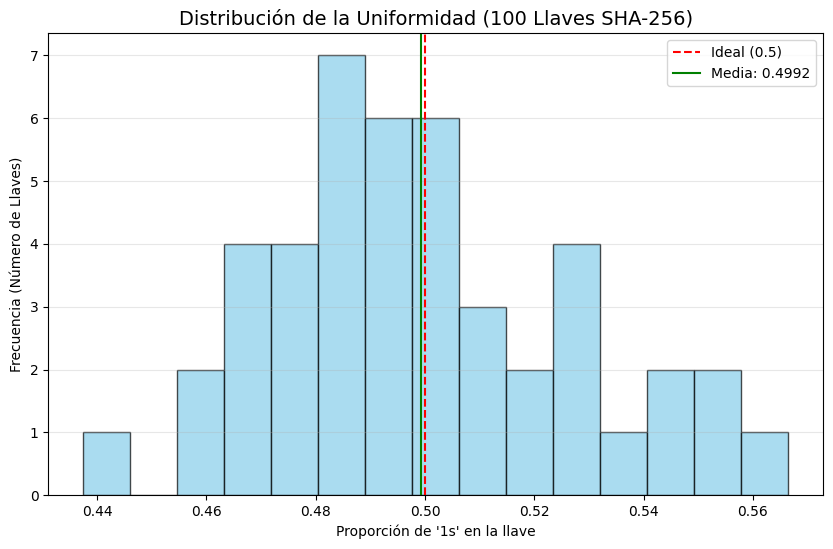

--- RESULTADOS ESTADÍSTICOS (N=100) ---
Uniformidad Media: 0.4992
Desviación Estándar: 0.0280
Rango: [0.4375 - 0.5664]

Resultado: EXCELENTE. Las llaves están perfectamente equilibradas.


In [129]:
# --- MÉTRICA: UNIFORMIDAD GLOBAL (100 RETOS) ---

# 1. Calculamos la uniformidad de cada una de las 100 llaves
# 'llaves_binarias' contiene las listas de 256 bits
proporciones_unos = [sum(llave) / len(llave) for llave in llaves_binarias]

# 2. Estadísticos globales
uniformidad_media = np.mean(proporciones_unos)
std_uniformidad = np.std(proporciones_unos)

# 3. Visualización de la distribución
plt.figure(figsize=(10, 6))
plt.hist(proporciones_unos, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(0.5, color='red', linestyle='--', label=f'Ideal (0.5)')
plt.axvline(uniformidad_media, color='green', linestyle='-', 
            label=f'Media: {uniformidad_media:.4f}')

plt.title("Distribución de la Uniformidad (100 Llaves SHA-256)", fontsize=14)
plt.xlabel("Proporción de '1s' en la llave")
plt.ylabel("Frecuencia (Número de Llaves)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"--- RESULTADOS ESTADÍSTICOS (N=100) ---")
print(f"Uniformidad Media: {uniformidad_media:.4f}")
print(f"Desviación Estándar: {std_uniformidad:.4f}")
print(f"Rango: [{np.min(proporciones_unos):.4f} - {np.max(proporciones_unos):.4f}]")

if 0.48 <= uniformidad_media <= 0.52:
    print("\nResultado: EXCELENTE. Las llaves están perfectamente equilibradas.")
else:
    print("\nResultado: Revisar posible sesgo.")

In [135]:
# --- MÉTRICA: FIABILIDAD (RELIABILITY) CON RUIDO ---

n_reto = 0
ruido_nivel = 0.03  # 1% de ruido sobre la potencia analógica

# 1. Recuperamos la huella original (sin ruido)
huella_original = matrices_sin_sesgo[n_reto].flatten()
bits_str_orig, _, _ = binarización(huella_original)
bits_orig = string_a_bits(bits_str_orig)
llave_orig = hashlib.sha256(bits_to_bytes_local(rellenar_a_byte(bits_orig))).hexdigest()

# 2. Generamos la huella con ruido (simulando una segunda lectura del chip)
# Añadimos ruido blanco gaussiano
ruido = np.random.normal(0, ruido_nivel, huella_original.shape)
huella_ruidosa = huella_original + ruido

# 3. Procesamos la huella ruidosa
bits_str_ruido, _, _ = binarización(huella_ruidosa)
bits_ruido = string_a_bits(bits_str_ruido)
llave_ruido = hashlib.sha256(bits_to_bytes_local(rellenar_a_byte(bits_ruido))).hexdigest()

# 4. Calculamos resultados
errores_bits = hamming_distance(bits_orig, bits_ruido)
ber = (errores_bits / len(bits_orig)) * 100  # Bit Error Rate en %

print(f"--- TEST DE FIABILIDAD (RETO #{n_reto}) ---")
print(f"Ruido inyectado: {ruido_nivel*100}%")
print(f"Bits que han cambiado: {errores_bits} de {len(bits_orig)}")
print(f"Tasa de Error de Bit (BER): {ber:.4f}%")
print(f"\nLlave Original: {llave_orig}")
print(f"Llave Ruidosa:  {llave_ruido}")

if llave_orig == llave_ruido:
    print("\n✅ ¡ÉXITO! El sistema es 100% FIABLE. La llave no ha cambiado.")
else:
    print("\n❌ LA LLAVE HA CAMBIADO. El ruido ha superado la capacidad del sistema.")

--- TEST DE FIABILIDAD (RETO #0) ---
Ruido inyectado: 3.0%
Bits que han cambiado: 1006 de 15560
Tasa de Error de Bit (BER): 6.4653%

Llave Original: d2ad428434380628253aa4d9b1a315231ffe259d3ce6b616f88913558639f3d5
Llave Ruidosa:  bf71afb0f936637e7cb297fec718afa4a5e304a7f0f96325dda151906ff63d91

❌ LA LLAVE HA CAMBIADO. El ruido ha superado la capacidad del sistema.


In [141]:
# --- TEST DE ESTRÉS: FIABILIDAD (RELIABILITY) ---

n_intentos = 20
ruido_nivel = 0.02  # 1% de ruido (bastante agresivo para fotónica)
n_reto = 0          # Vamos a testear siempre el mismo reto

# Inicializar el motor BCH (t=30, m=13 como acordamos para evitar errores)
bch = bchlib.BCH(t=30, m=13)

# 1. ENROLLMENT (Día 1: Registro de la "Llave Maestra")
huella_base = matrices_sin_sesgo[n_reto].flatten()
bits_o_str, _, _ = binarización(huella_base)
bits_o_lista = string_a_bits(bits_o_str)

# Generamos los "Helper Data" (datos de paridad)
helper_data = puf_enrollment(bits_o_lista, bch)
llave_maestra = generar_hash_sha256(b"".join([bits_to_bytes_local(rellenar_a_byte(list(f))) for f in np.array_split(bits_o_lista, 64)]))

# 2. RECONSTRUCTION (Simulación de 20 intentos de acceso con ruido)
resultados = []
errores_corregidos_lista = []

print(f"Iniciando test de fiabilidad para {n_intentos} intentos con {ruido_nivel*100}% de ruido...")

for i in range(n_intentos):
    # Añadimos ruido aleatorio diferente en cada intento
    huella_ruidosa = huella_base + np.random.normal(0, ruido_nivel, huella_base.shape)
    
    # Binarizamos la huella sucia
    bits_r_str, _, _ = binarización(huella_ruidosa)
    bits_r_lista = string_a_bits(bits_r_str)
    
    # Intentamos reconstruir la llave usando el Helper Data
    bytes_limpios, n_err = puf_reconstruction(bits_r_lista, helper_data, bch)
    llave_intento = generar_hash_sha256(bytes_limpios)
    
    # Comprobamos si la llave es idéntica
    exito = (llave_intento == llave_maestra)
    resultados.append(exito)
    errores_corregidos_lista.append(n_err)
    
    print(f" Intento {i+1:02d}: {n_err} errores corregidos | {'✅ ÉXITO' if exito else '❌ FALLO'}")

# --- 3. MÉTRICAS FINALES ---
tasa_exito = (sum(resultados) / n_intentos) * 100
ber_medio = (np.mean(errores_corregidos_lista) / 15560) * 100

print(f"\n--- INFORME DE ROBUSTEZ ---")
print(f"Tasa de éxito (Reliability): {tasa_exito}%")
print(f"BER medio (antes de corregir): {ber_medio:.4f}%")
print(f"Máximos errores encontrados en un bloque: {max(errores_corregidos_lista)}")

if tasa_exito == 100:
    print("\n¡CONLUSIÓN: Tu PUF es una roca! El sistema es totalmente resistente al ruido.")
else:
    print("\n¡ATENCIÓN: El ruido ha vencido al BCH en algunos intentos. Considera subir 't' o bajar el ruido.")

Iniciando test de fiabilidad para 20 intentos con 2.0% de ruido...
 Intento 01: 853 errores corregidos | ✅ ÉXITO
 Intento 02: 855 errores corregidos | ✅ ÉXITO
 Intento 03: 846 errores corregidos | ✅ ÉXITO
 Intento 04: 874 errores corregidos | ✅ ÉXITO
 Intento 05: 801 errores corregidos | ✅ ÉXITO
 Intento 06: 819 errores corregidos | ✅ ÉXITO
 Intento 07: 844 errores corregidos | ✅ ÉXITO
 Intento 08: 853 errores corregidos | ✅ ÉXITO
 Intento 09: 817 errores corregidos | ✅ ÉXITO
 Intento 10: 848 errores corregidos | ✅ ÉXITO
 Intento 11: 887 errores corregidos | ✅ ÉXITO
 Intento 12: 854 errores corregidos | ✅ ÉXITO
 Intento 13: 858 errores corregidos | ✅ ÉXITO
 Intento 14: 879 errores corregidos | ✅ ÉXITO
 Intento 15: 837 errores corregidos | ✅ ÉXITO
 Intento 16: 832 errores corregidos | ✅ ÉXITO
 Intento 17: 878 errores corregidos | ✅ ÉXITO
 Intento 18: 849 errores corregidos | ✅ ÉXITO
 Intento 19: 812 errores corregidos | ✅ ÉXITO
 Intento 20: 811 errores corregidos | ✅ ÉXITO

--- INFORME 

Iniciando simulación empírica (Monte Carlo)...
Procesando 10 niveles de ruido, por favor espera...
 -> SNR: 23.0 dB (Ruido 0.5%) | Fiabilidad: 100.0%
 -> SNR: 20.0 dB (Ruido 1.0%) | Fiabilidad: 100.0%
 -> SNR: 18.2 dB (Ruido 1.5%) | Fiabilidad: 100.0%
 -> SNR: 17.0 dB (Ruido 2.0%) | Fiabilidad: 100.0%
 -> SNR: 16.0 dB (Ruido 2.5%) | Fiabilidad: 85.0%
 -> SNR: 15.2 dB (Ruido 3.0%) | Fiabilidad: 55.00000000000001%
 -> SNR: 14.6 dB (Ruido 3.5%) | Fiabilidad: 10.0%
 -> SNR: 14.0 dB (Ruido 4.0%) | Fiabilidad: 0.0%
 -> SNR: 13.5 dB (Ruido 4.5%) | Fiabilidad: 0.0%
 -> SNR: 13.0 dB (Ruido 5.0%) | Fiabilidad: 0.0%


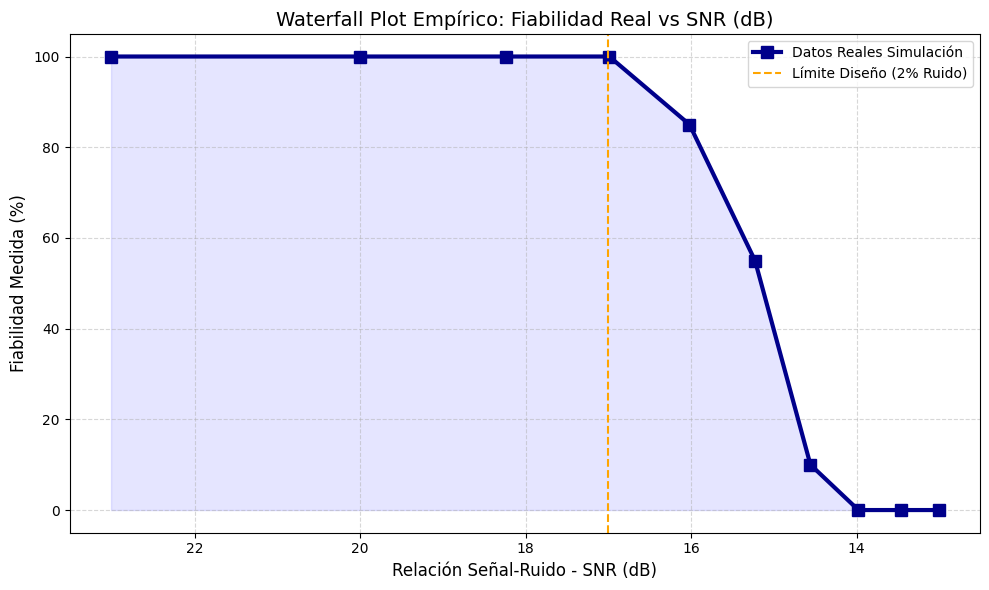

In [142]:
import numpy as np
import matplotlib.pyplot as plt
import bchlib
import hashlib
import math

# --- CONFIGURACIÓN DEL EXPERIMENTO REAL ---
n_intentos_por_nivel = 20  # Cuántas veces probamos cada nivel de ruido
niveles_ruido = np.linspace(0.005, 0.05, 10)  # De 0.5% a 5.0% de ruido
bch = bchlib.BCH(t=30, m=13)  # Usamos la configuración de 64 bloques que nos funcionó

# 1. ENROLLMENT (Día 1: Datos limpios del Reto #0)
huella_base = matrices_sin_sesgo[0].flatten()
bits_o_str, _, _ = binarización(huella_base)
bits_o_lista = string_a_bits(bits_o_str)

# Generamos la paridad (Helper Data) original
helper_data = puf_enrollment(bits_o_lista, bch)
# Calculamos la llave maestra original
bytes_orig_completos = b"".join([bits_to_bytes_local(rellenar_a_byte(list(f))) for f in np.array_split(bits_o_lista, 64)])
llave_maestra = generar_hash_sha256(bytes_orig_completos)

# 2. SIMULACIÓN EMPÍRICA (Monte Carlo)
fiabilidades_reales = []
snr_db_reales = []

print(f"Iniciando simulación empírica (Monte Carlo)...")
print(f"Procesando {len(niveles_ruido)} niveles de ruido, por favor espera...")

for p_ruido in niveles_ruido:
    exitos = 0
    snr_db = 10 * np.log10(1 / p_ruido)
    snr_db_reales.append(snr_db)
    
    for _ in range(n_intentos_por_nivel):
        # Generar ruido real sobre tu matriz
        huella_ruidosa = huella_base + np.random.normal(0, p_ruido, huella_base.shape)
        
        # Binarización y reconstrucción real
        bits_r_str, _, _ = binarización(huella_ruidosa)
        bits_r_lista = string_a_bits(bits_r_str)
        
        try:
            bytes_limpios, _ = puf_reconstruction(bits_r_lista, helper_data, bch)
            llave_intento = generar_hash_sha256(bytes_limpios)
            
            if llave_intento == llave_maestra:
                exitos += 1
        except:
            # Si el BCH falla catastróficamente, contamos como fallo
            pass
            
    fiabilidad = (exitos / n_intentos_por_nivel) * 100
    fiabilidades_reales.append(fiabilidad)
    print(f" -> SNR: {snr_db:.1f} dB (Ruido {p_ruido*100:.1f}%) | Fiabilidad: {fiabilidad}%")

# --- 3. VISUALIZACIÓN DE DATOS REALES ---
plt.figure(figsize=(10, 6))
plt.plot(snr_db_reales, fiabilidades_reales, marker='s', markersize=8, 
         linestyle='-', linewidth=3, color='darkblue', label='Datos Reales Simulación')

plt.fill_between(snr_db_reales, fiabilidades_reales, color='blue', alpha=0.1)

# Estética de la gráfica
plt.title('Waterfall Plot Empírico: Fiabilidad Real vs SNR (dB)', fontsize=14)
plt.xlabel('Relación Señal-Ruido - SNR (dB)', fontsize=12)
plt.ylabel('Fiabilidad Medida (%)', fontsize=12)
plt.gca().invert_xaxis()  # El ruido aumenta hacia la derecha
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.ylim(-5, 105)

# Líneas de referencia
plt.axvline(17, color='orange', linestyle='--', label='Límite Diseño (2% Ruido)')
plt.legend()

plt.tight_layout()
plt.show()

Iniciando Test Multiclave (5 retos x 10 niveles)...

Analizando Reto #0...
  Ruido 5.0% -> Fiabilidad: 0.0%6666666666667%
Analizando Reto #1...
  Ruido 5.0% -> Fiabilidad: 0.0%66666666666668%
Analizando Reto #2...
  Ruido 5.0% -> Fiabilidad: 0.0%6666666666667%%
Analizando Reto #3...
  Ruido 5.0% -> Fiabilidad: 0.0%33333333333334%
Analizando Reto #4...


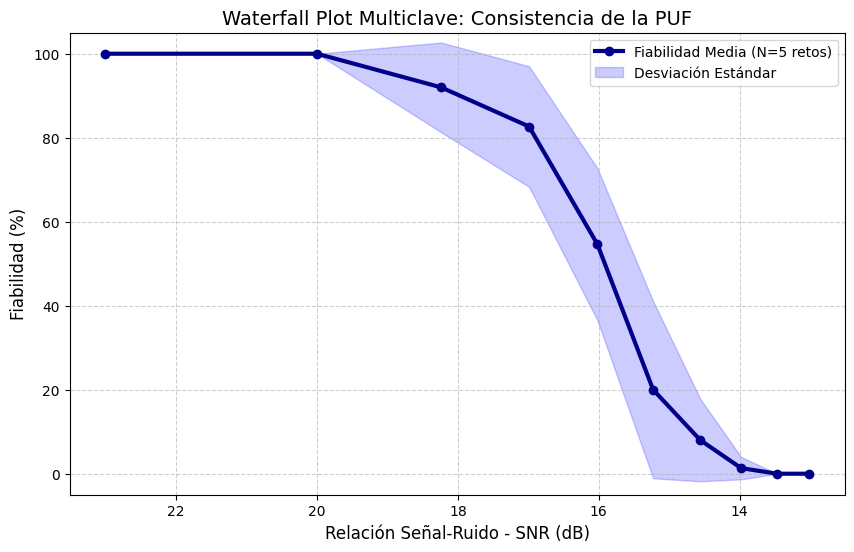

In [144]:
import numpy as np
import matplotlib.pyplot as plt
import bchlib
import hashlib

# --- CONFIGURACIÓN DEL EXPERIMENTO MULTI-CLAVE ---
n_retos_a_testear = 5      # Probamos con 5 retos diferentes
n_intentos_por_nivel = 15  # 15 repeticiones ruidosas por cada nivel
niveles_ruido = np.linspace(0.005, 0.05, 10) # 8 niveles de ruido
bch = bchlib.BCH(t=30, m=13)

# Diccionario para guardar resultados de cada reto
resultados_globales = np.zeros((n_retos_a_testear, len(niveles_ruido)))

print(f"Iniciando Test Multiclave ({n_retos_a_testear} retos x {len(niveles_ruido)} niveles)...")

for idx_reto in range(n_retos_a_testear):
    print(f"\nAnalizando Reto #{idx_reto}...")
    
    # 1. ENROLLMENT del Reto actual
    huella_base = matrices_sin_sesgo[idx_reto].flatten()
    bits_o_str, _, _ = binarización(huella_base)
    bits_o_lista = string_a_bits(bits_o_str)
    helper_data = puf_enrollment(bits_o_lista, bch)
    
    # Llave maestra del reto actual
    bytes_orig = b"".join([bits_to_bytes_local(rellenar_a_byte(list(f))) for f in np.array_split(bits_o_lista, 64)])
    llave_maestra = generar_hash_sha256(bytes_orig)

    # 2. Bucle de Ruido
    for idx_ruido, p_ruido in enumerate(niveles_ruido):
        exitos = 0
        for _ in range(n_intentos_por_nivel):
            huella_ruidosa = huella_base + np.random.normal(0, p_ruido, huella_base.shape)
            bits_r_str, _, _ = binarización(huella_ruidosa)
            bits_r_lista = string_a_bits(bits_r_str)
            
            try:
                bytes_limpios, _ = puf_reconstruction(bits_r_lista, helper_data, bch)
                if generar_hash_sha256(bytes_limpios) == llave_maestra:
                    exitos += 1
            except: pass
            
        fiabilidad = (exitos / n_intentos_por_nivel) * 100
        resultados_globales[idx_reto, idx_ruido] = fiabilidad
        print(f"  Ruido {p_ruido*100:.1f}% -> Fiabilidad: {fiabilidad}%", end="\r")

# --- 3. PROCESADO DE ESTADÍSTICAS ---
fiabilidad_media = np.mean(resultados_globales, axis=0)
fiabilidad_std = np.std(resultados_globales, axis=0)
snr_db_axis = 10 * np.log10(1 / niveles_ruido)

# --- 4. GRÁFICA FINAL ---
plt.figure(figsize=(10, 6))

# Dibujamos la media
plt.plot(snr_db_axis, fiabilidad_media, 'o-', linewidth=3, color='darkblue', label='Fiabilidad Media (N=5 retos)')

# Dibujamos el área de desviación (Sombreado)
# Esto muestra si hay retos que se comportan mucho peor que otros
plt.fill_between(snr_db_axis, fiabilidad_media - fiabilidad_std, 
                 fiabilidad_media + fiabilidad_std, color='blue', alpha=0.2, label='Desviación Estándar')

plt.title('Waterfall Plot Multiclave: Consistencia de la PUF', fontsize=14)
plt.xlabel('Relación Señal-Ruido - SNR (dB)', fontsize=12)
plt.ylabel('Fiabilidad (%)', fontsize=12)
plt.gca().invert_xaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-5, 105)
plt.legend()
plt.show()